# Trabajo Semanal N°6 : 'Transformada Z y Respuesta en frecuencia'
### Alumno: Magdalena Guida

### APS - 1er cuatrimestre 2026


Este trabajo tiene como objetivo el analisis de distintas ecuaciones en diferencias que representan un sistema que dan lugar a filtros de media movil y filtros diferenciadores. Para lograrlo se calcula la transformada $T(z)$, la respuesta en frecuencia de modulo y fase, tanto con el calculo manual como simulandolos con las herramientas de Numpy en Spyder.  

Las 4 ecuaciones son: 
- $y_1(n) = x(n-3) + x(n-2) + x(n-1) + x(n) $
- $y_2(n) = x(n-4) + x(n-3) + x(n-2) + x(n-1) + x(n) $
- $y_3(n) = x(n) - x(n-1) $
- $y_4(n) = x(n) - x(n-2) $


Primero, el calculo de la funcion transferencia $T(z) = \frac{Y(z)}{X(z)}$, que es la representacion del filtro en el dominio $z$ y puede describir como el sistema transformara cualquier señal de entrada. Ademas, da informacion acerca de los ***polos***, ***ceros*** y el ***grado***. Esos datos pueden determinar propiedades del sistema como: diferenciar entre filtro **FIR** o **IIR**, la estabilidad y la fase lineal. 

Luego, se evaluaron en $z = e^{jw}$, para obtener la respuesta en frecuencia compleja. En el calculo manual se aplicaron las siguientes derivadas de la formula de Euler.

- Formula del seno complejo:
                          $2j\sin(x) = e^{jx} - e^{-jx}$
- Formula del coseno:
                          $2\cos(x) = e^{jx} + e^{-jx}$
- Identidad trigonometrica de suma a producto:
                          $ cos(A) + cos(B) = 2\cos(\frac{A+B}{2})\cos(\frac{A-B}{2})$

Utilizando las ecuaciones $T(z)$ y $T(e^jw)$ de cada sistema se calcularon sus ceros y polos igualando el  numerador y denominador a cero, respectivamente y se graficaron en el plano $z$ sobre la circunferencia de $radio =1$. A continuacion, se projectan los calculos y graficos:

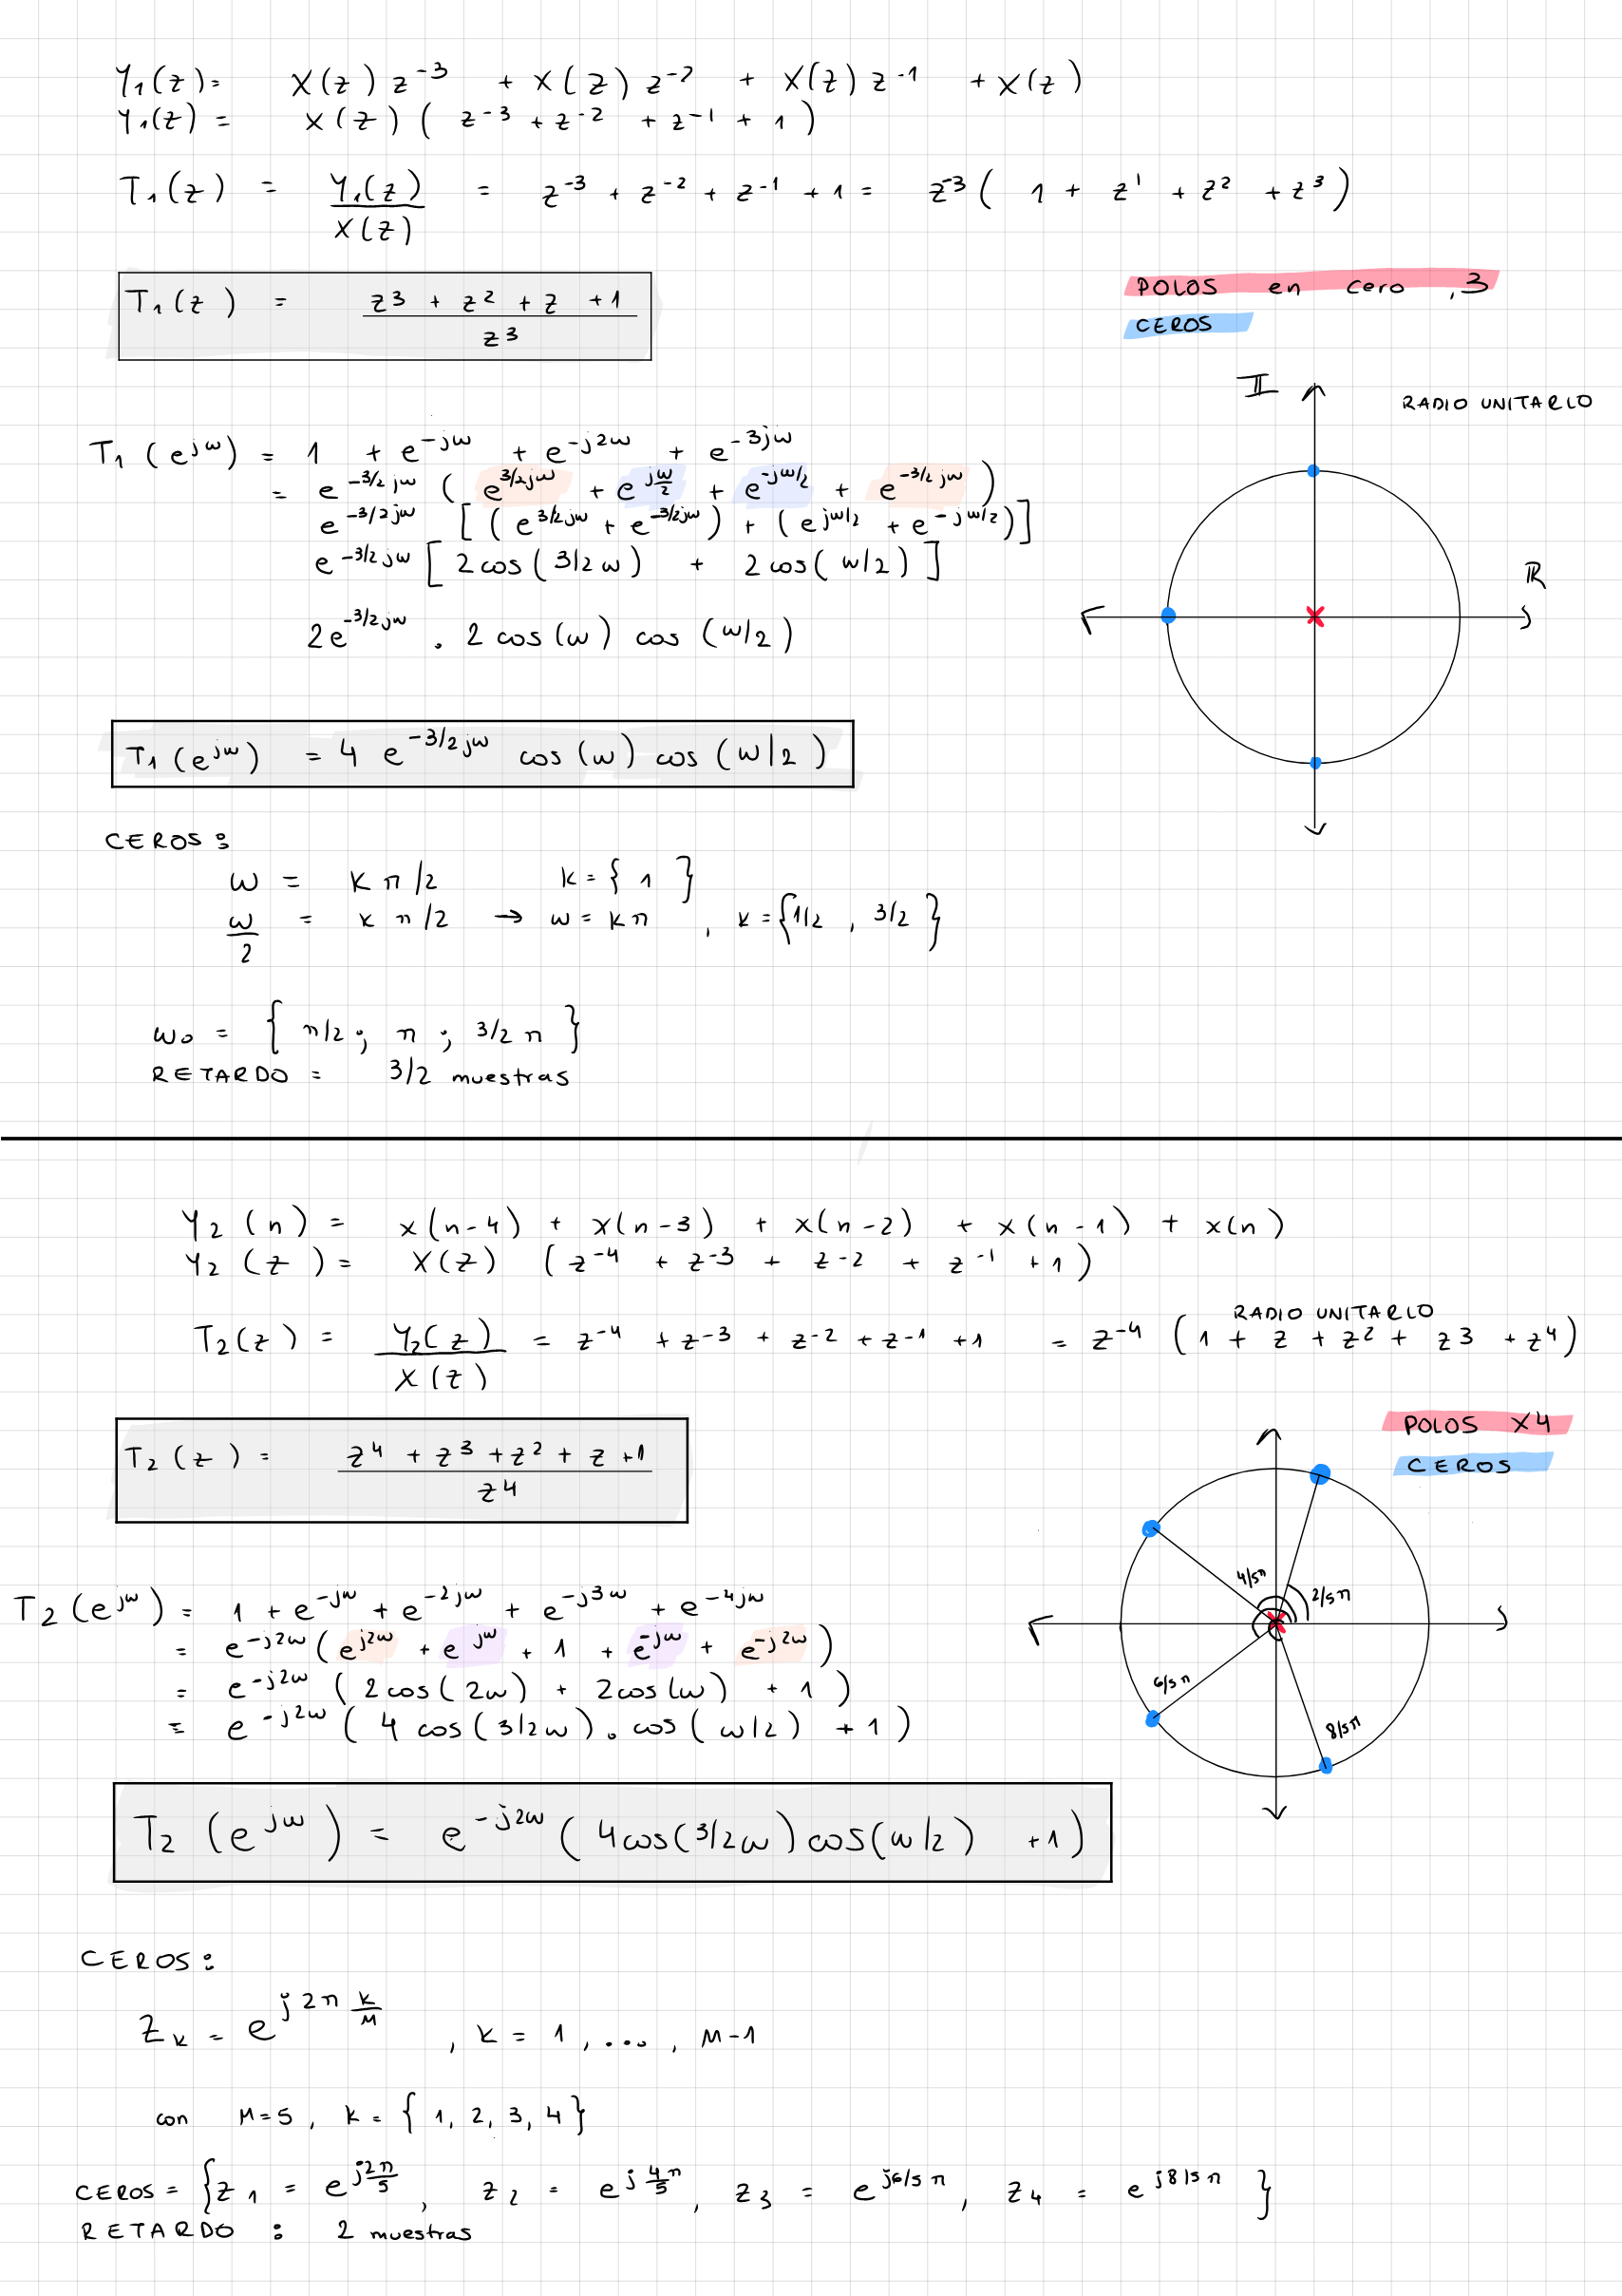

In [3]:
from IPython.display import Image 
Image(r"..\TS 6\polosyceros.1.png")

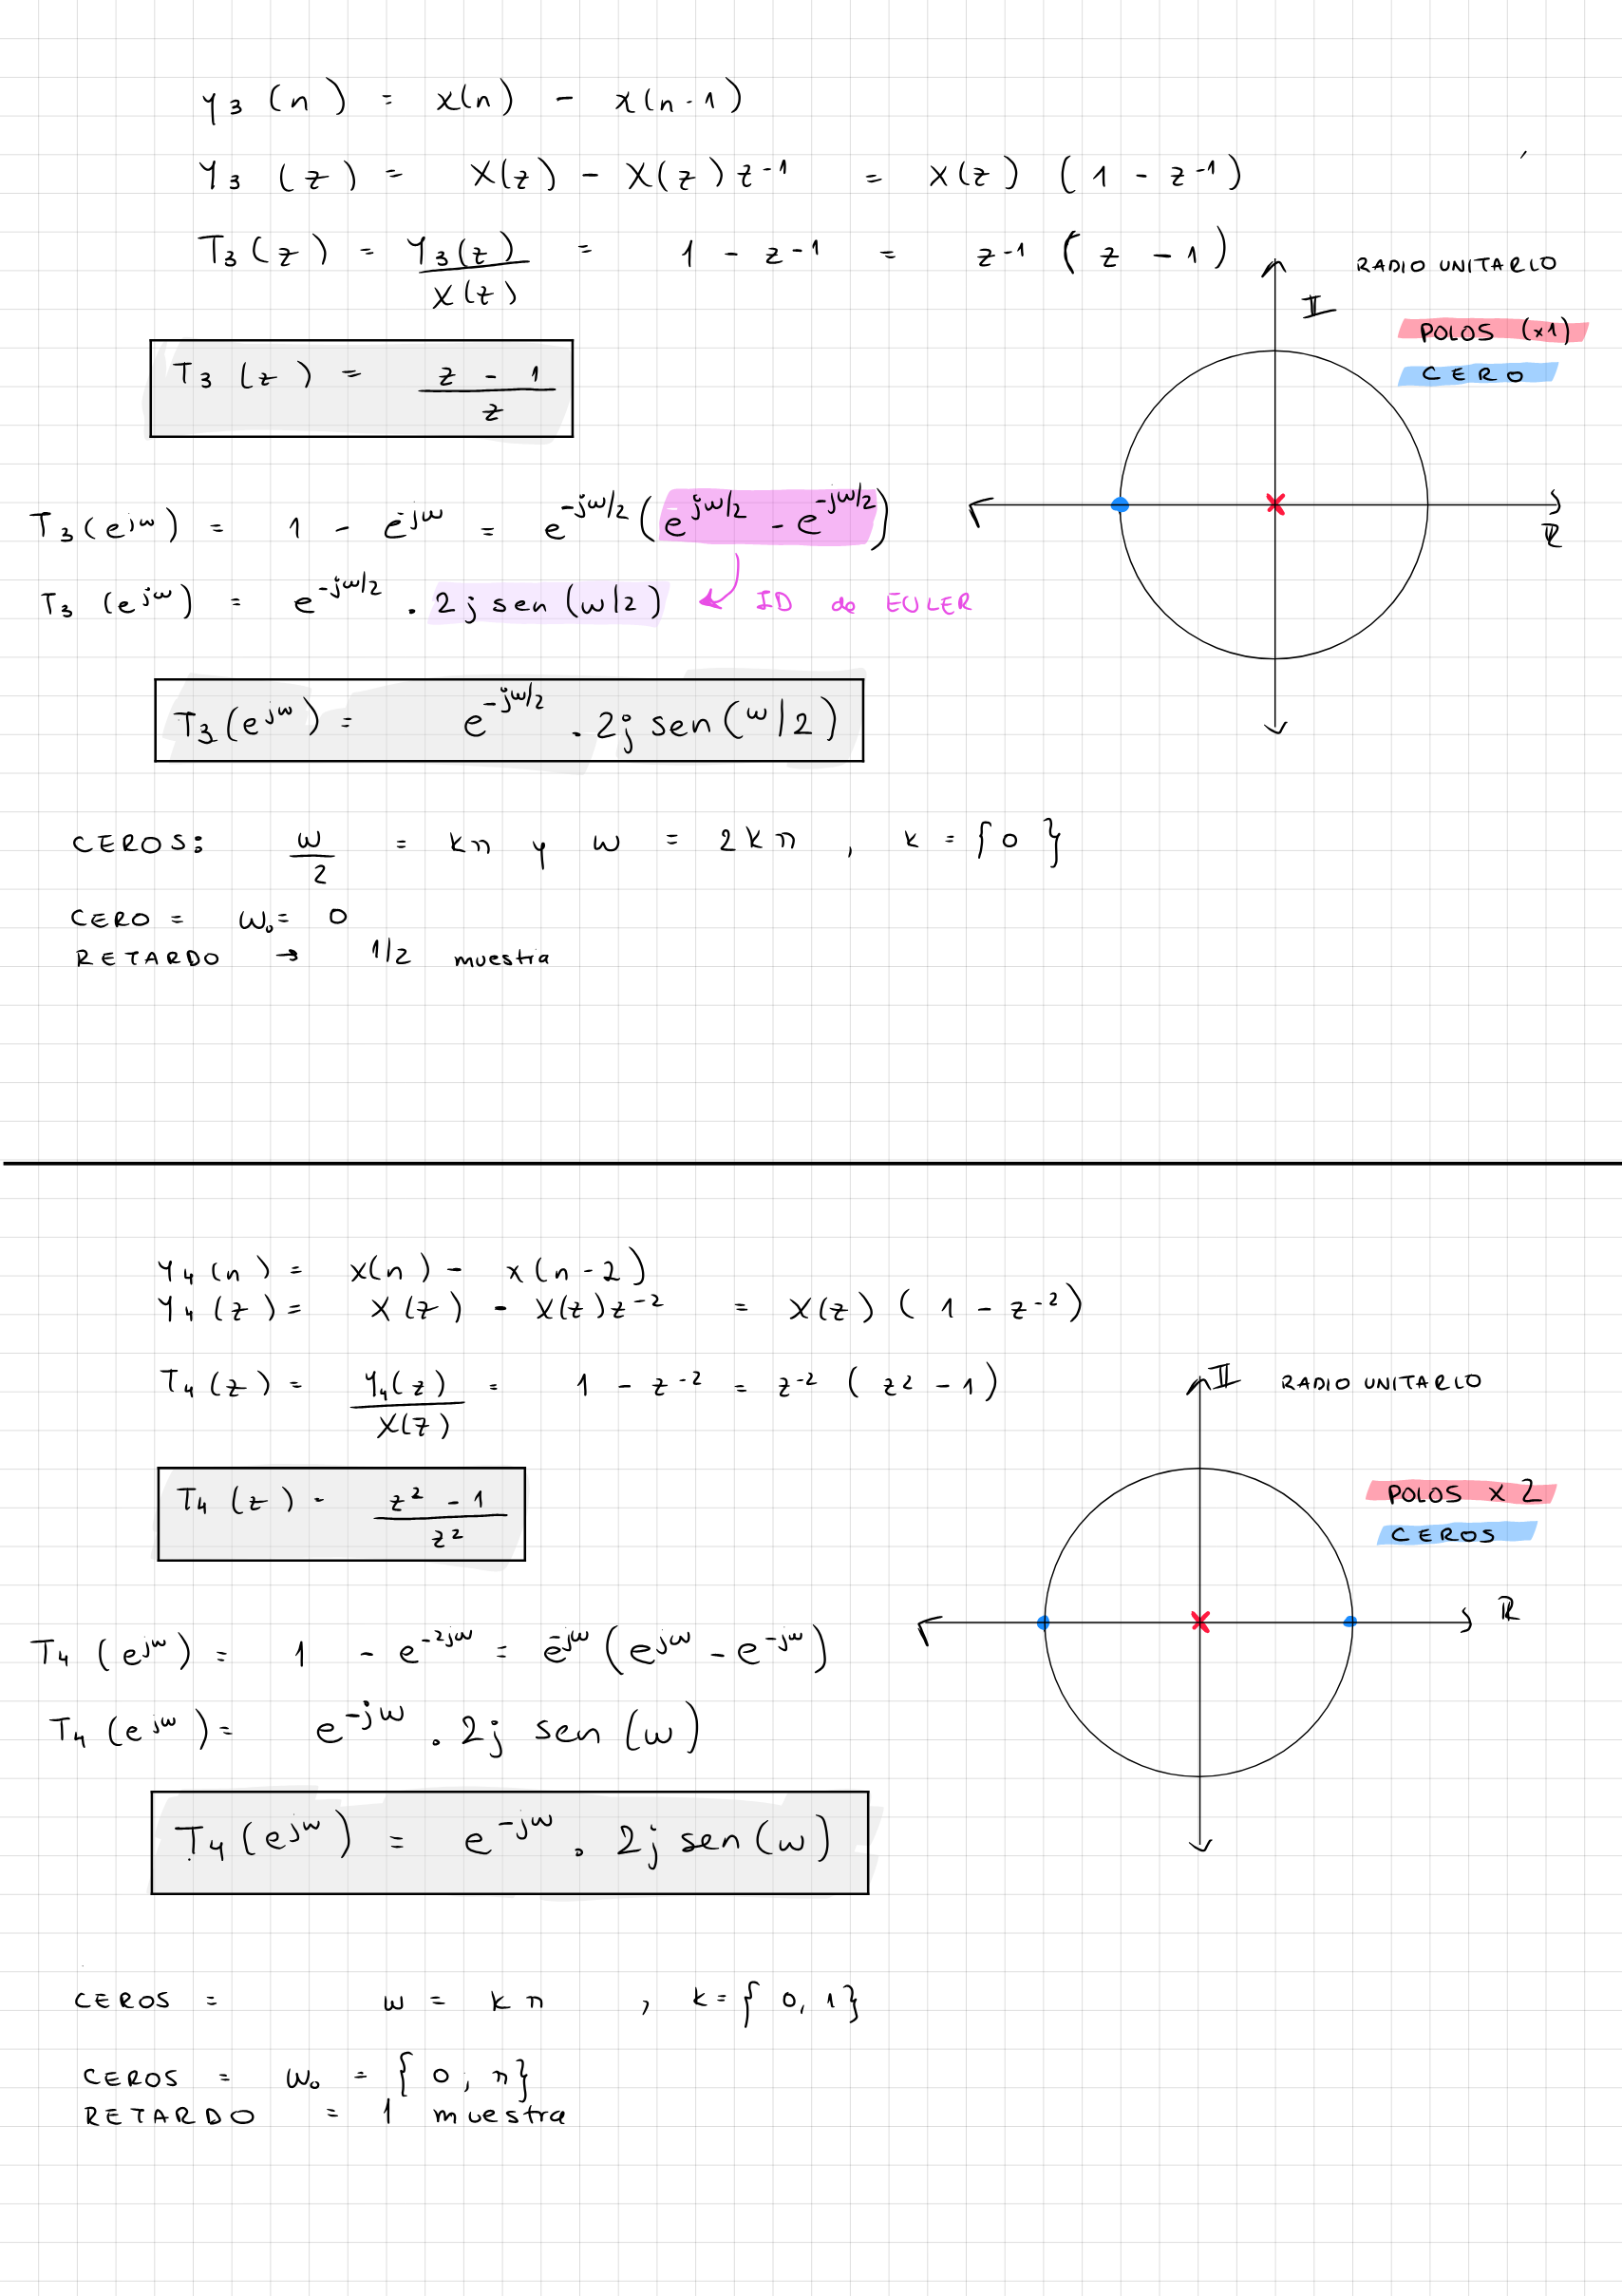

In [4]:
from IPython.display import Image 
Image(r"..\TS 6\polosyceros.2.png")

En segundo lugar, se calculo el modulo de la Transformada: $|T|$, y evaluandola en puntos especificos como: $[0,\frac{\pi}{4}, \frac{\pi}{2}, \pi, \frac{3\pi}{4}, ceros]$ se puede deducir la forma que toma su respuesta en frecuencia. Los valores 'en escala lineal' de la Transformada con modulo, no tienen unidades. Se los convierte en $[dB]$, aplicandoles: $20\ log(x) $, se los grafica en *Frecuencia* $[\frac{rad}{s}]$ vs *Magnitud* $[dB]$. Tambien, se calcula su respuesta de fase $\angle T$ sabiendo que el aporte de fases de un producto es la suma de sus fases individuales. 

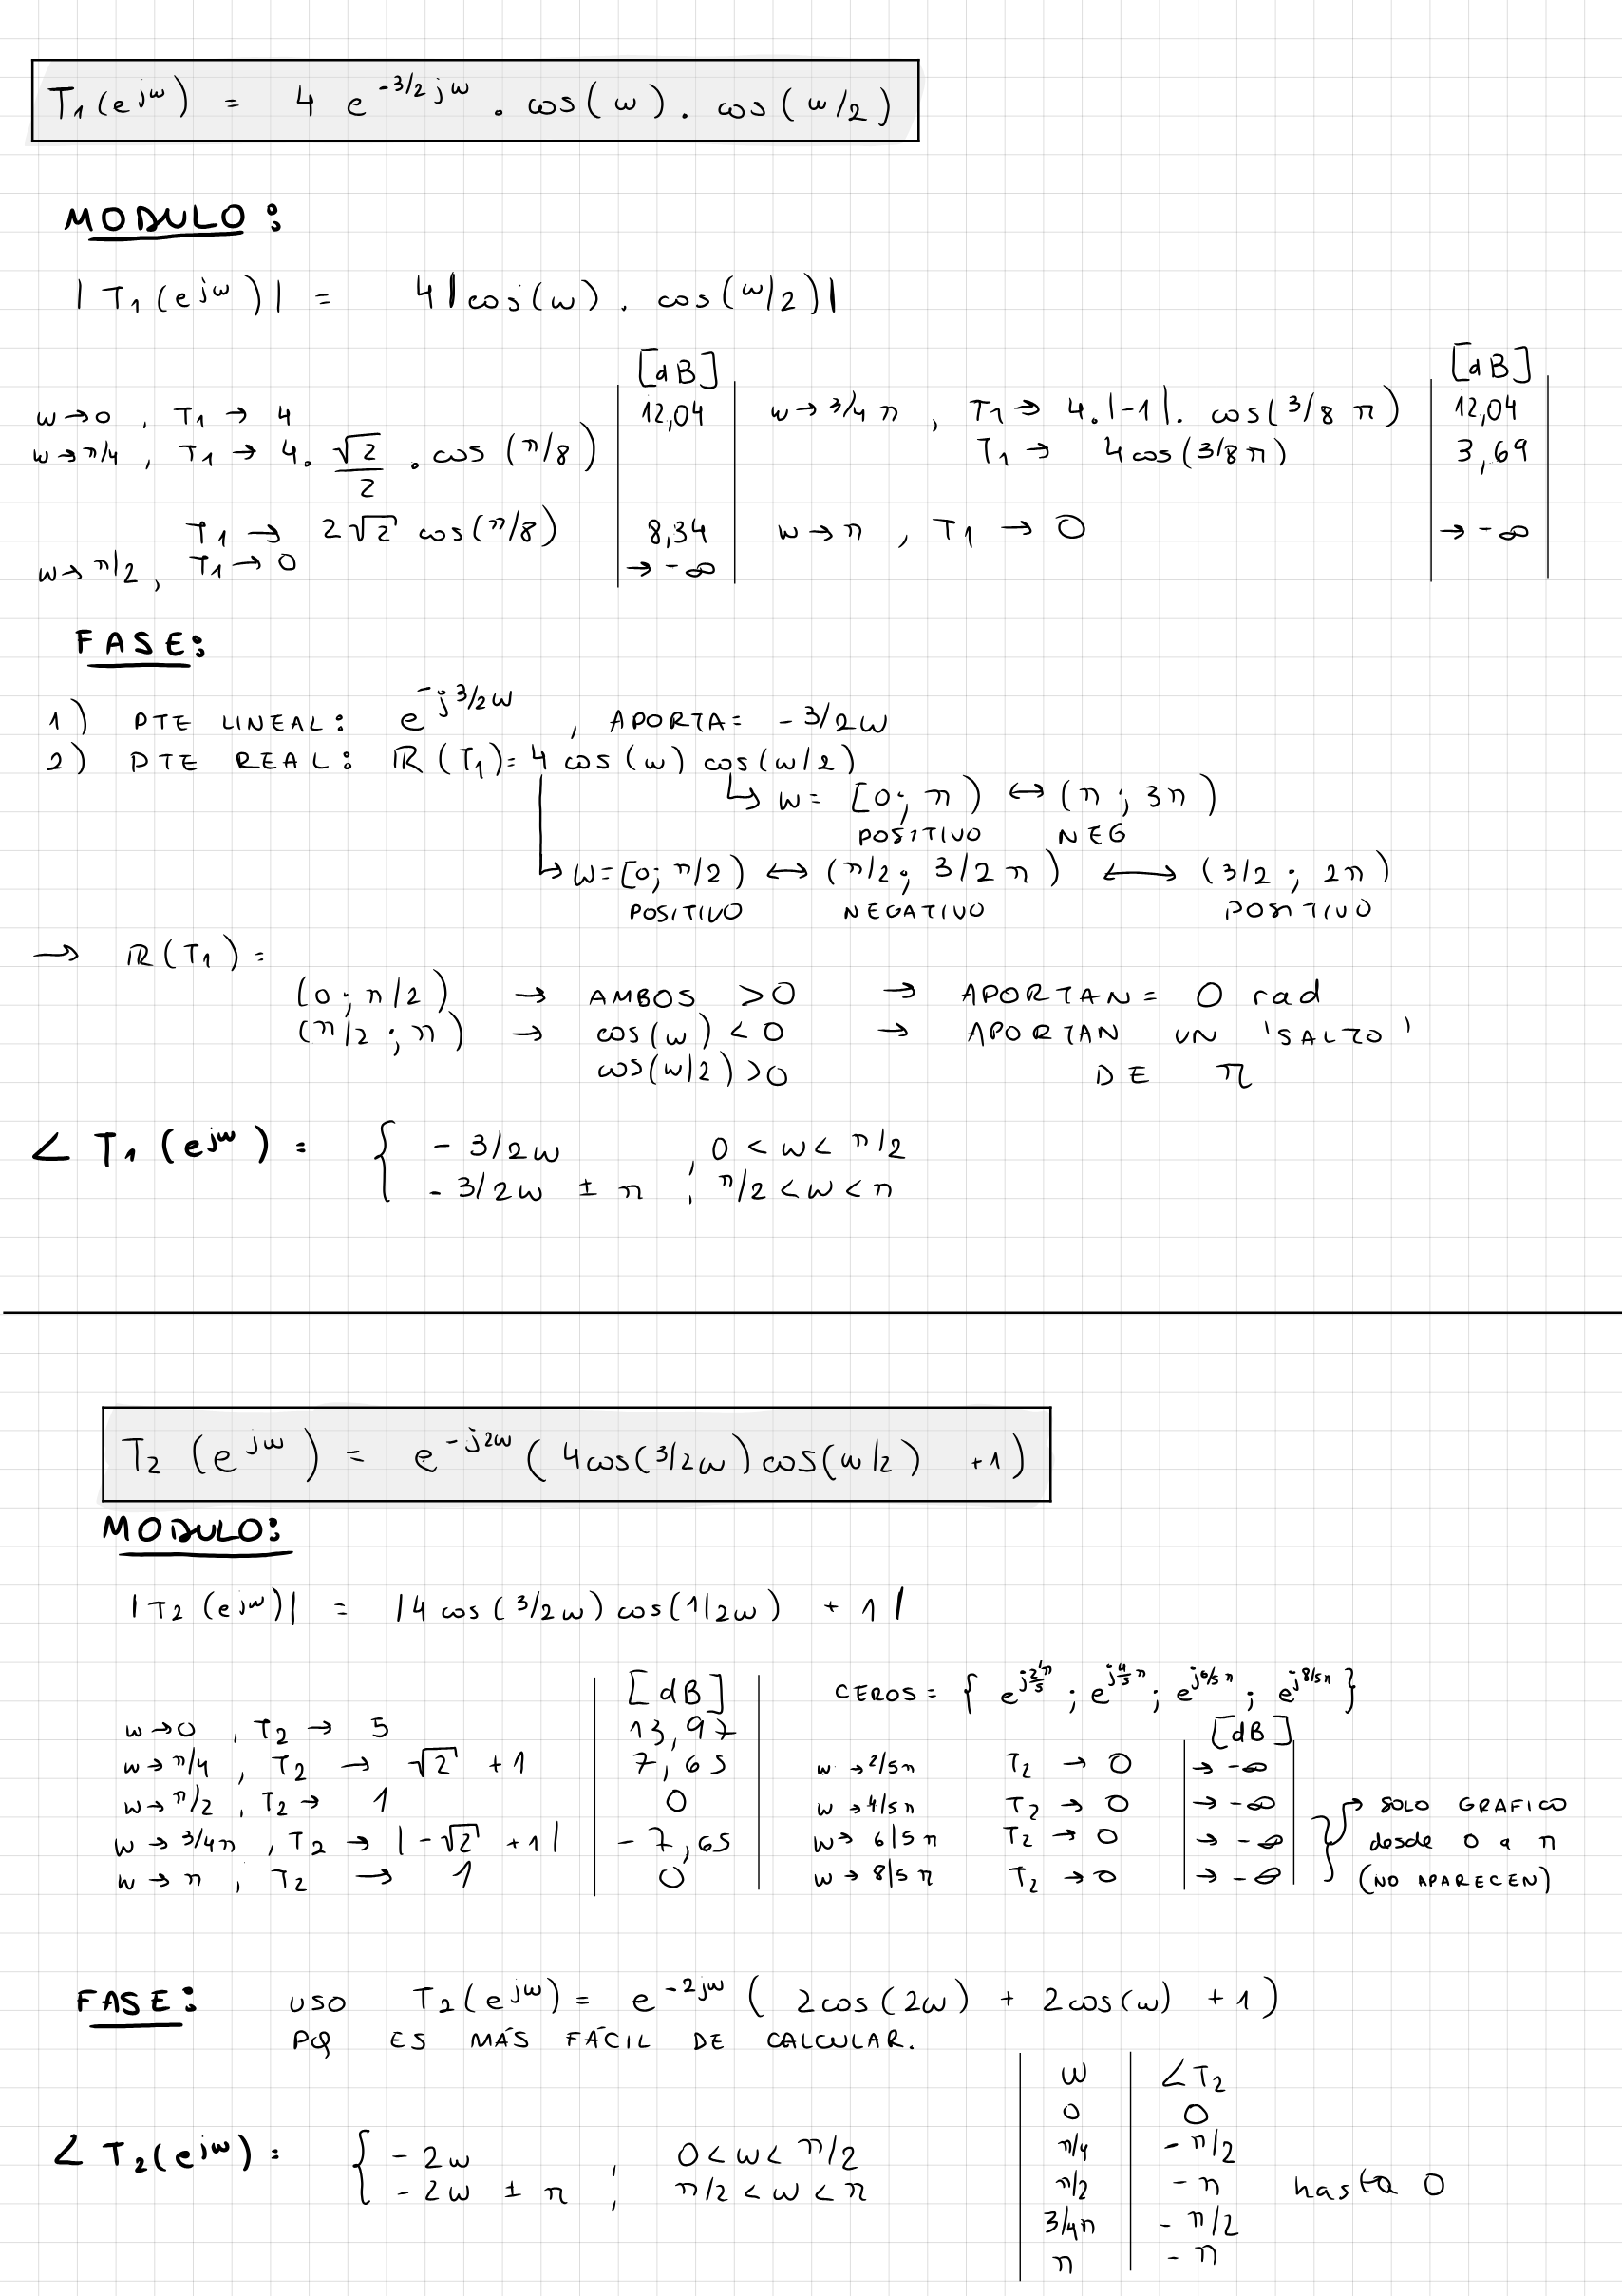

In [5]:
from IPython.display import Image 
Image(r"..\TS 6\calcmodyfase.1.png")

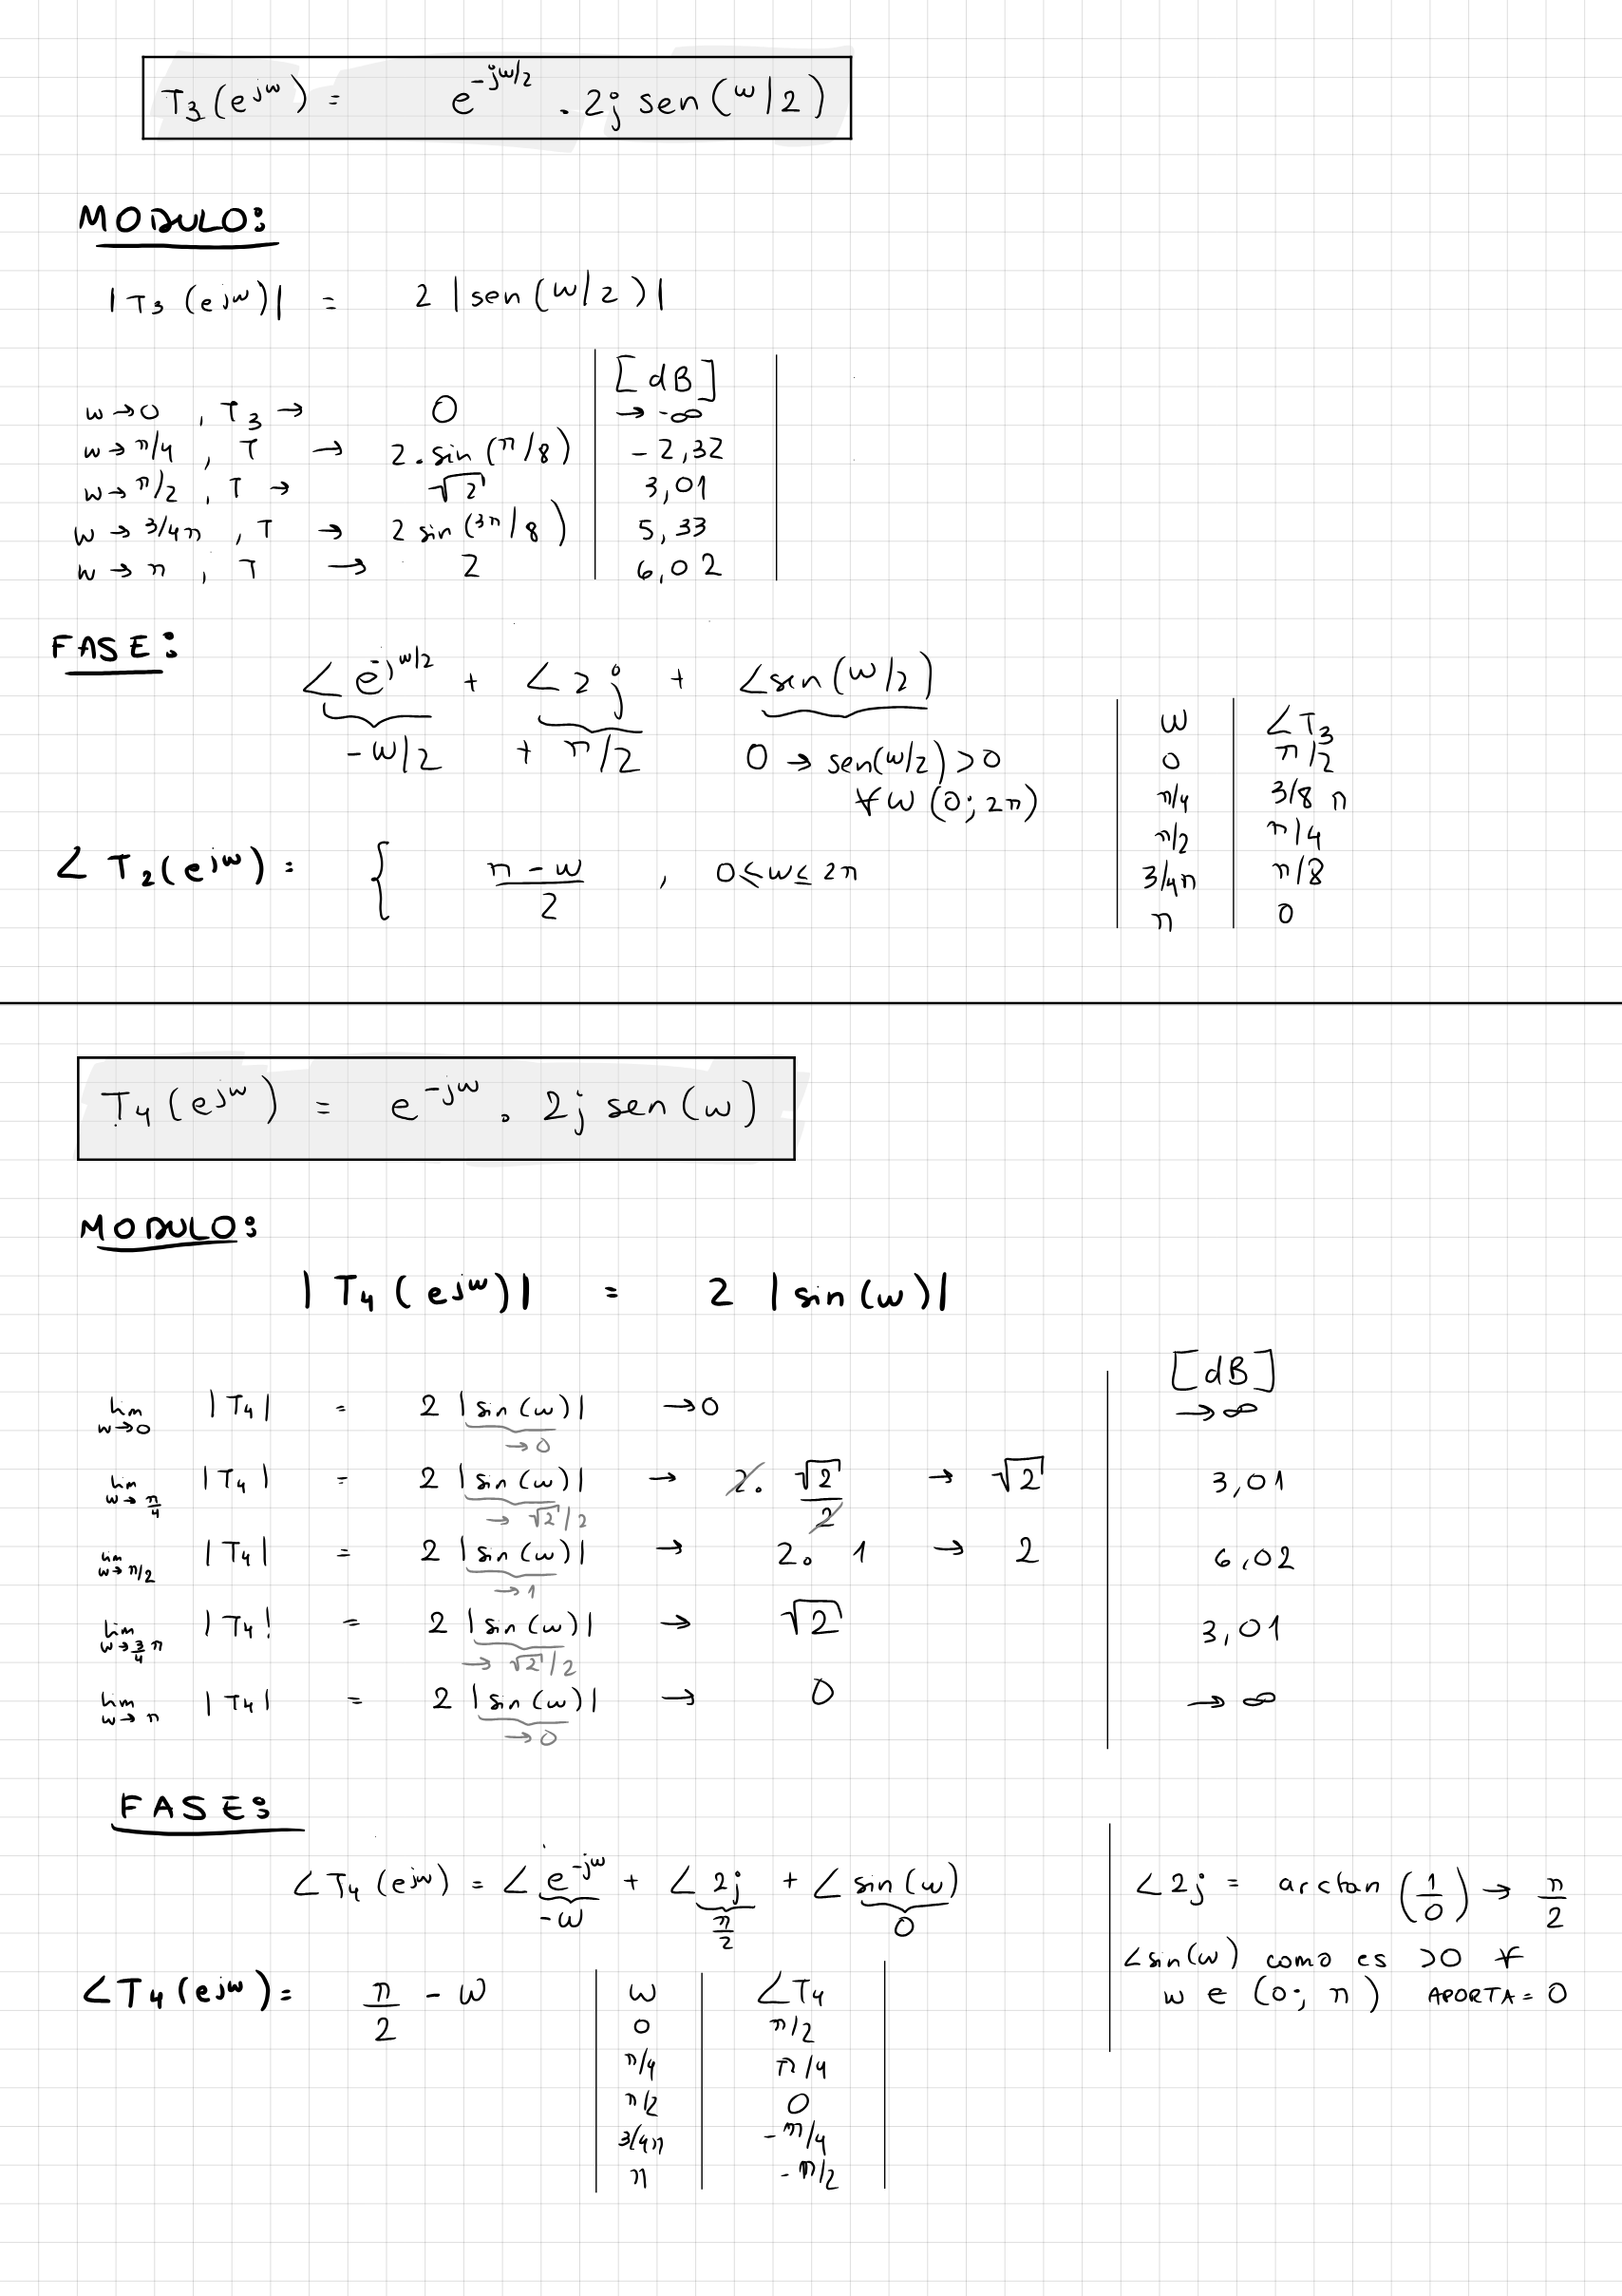

In [8]:
from IPython.display import Image 
Image(r"..\TS 6\calcmodyfase.2.png")

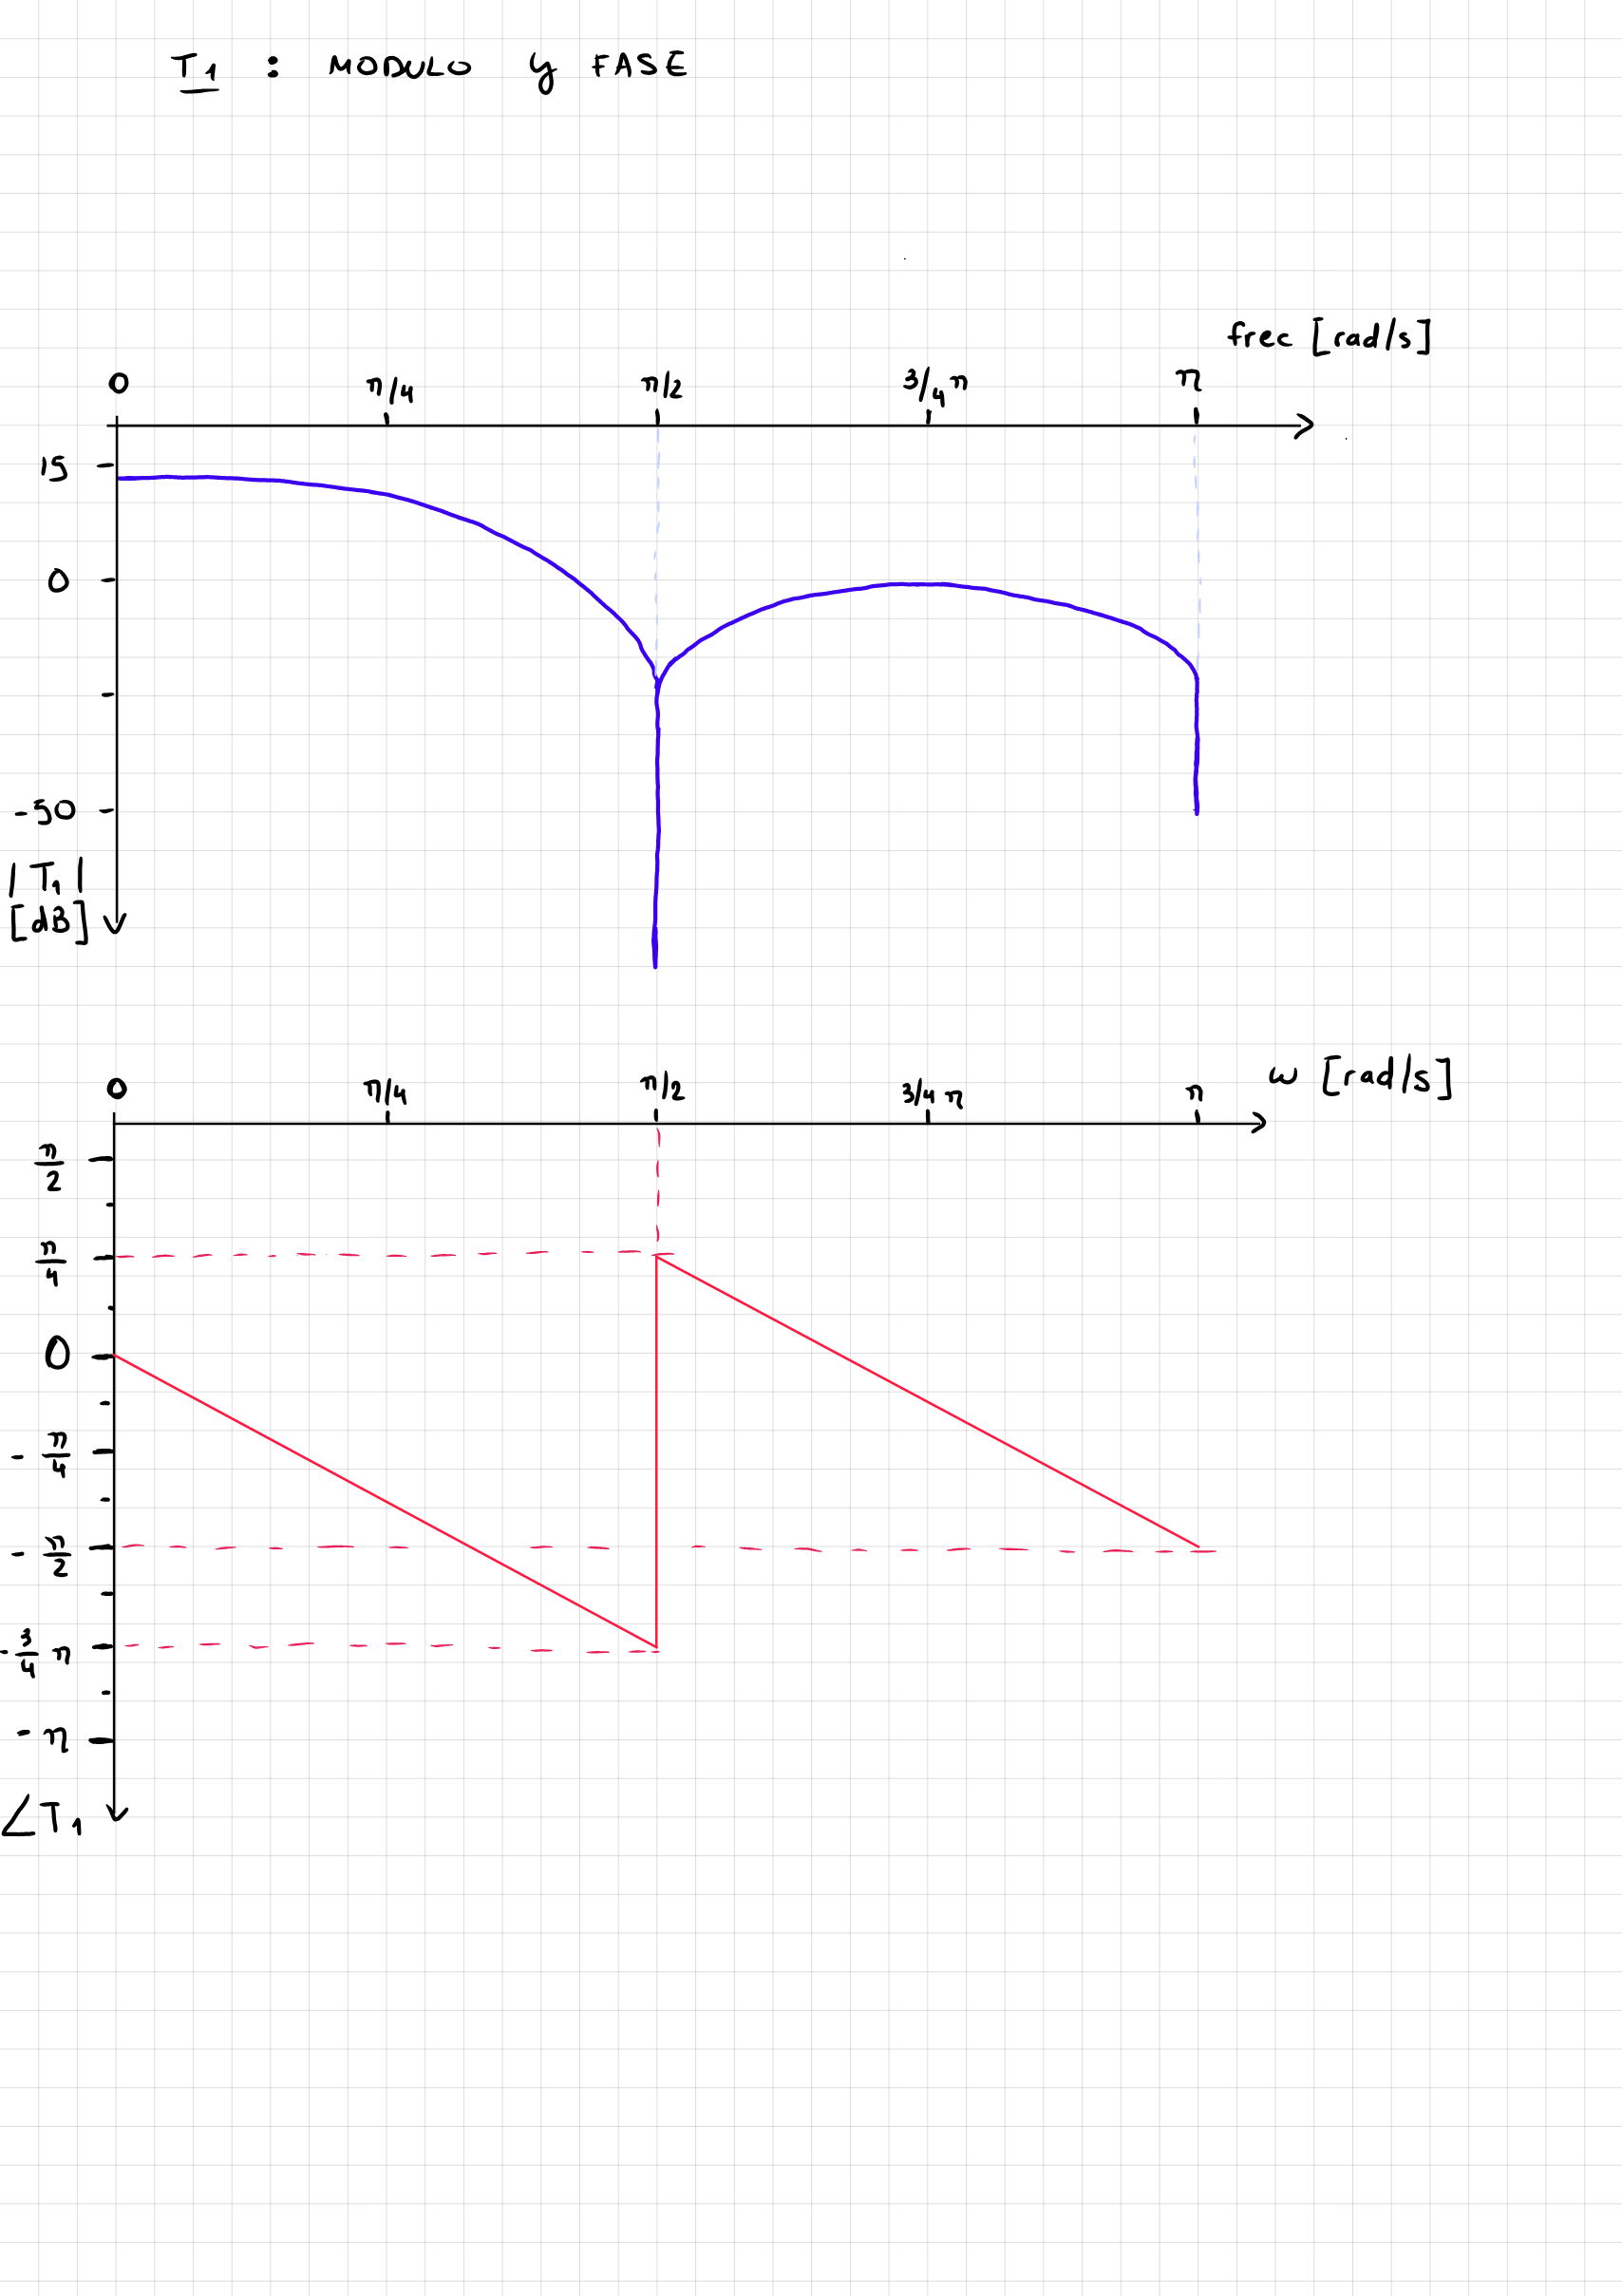

In [9]:
from IPython.display import Image 
Image(r"..\TS 6\grafT1.png")

$T_1$ representa un filto **FIR** pasa-bajos de ***Tipo II***. Sus coeficientes: $[1, 1, 1, 1]$ tienen largo par y $N = 3$ y son simetricos, ya que $h[0] = h[3] = 1$ ^ $h[1] = h[2] = 1$, ambas indicaciones de un filtro de este tipo. En la grafica de respuesta de modulo, lo indica el cero en $\pi$, tambien hay un segundo cero no forzado en $w_0 = \frac{\pi}{2}$, que obliga a que la caida sea mas abrupta y permite pasar menos frcuencias, lo convierte en un filtro mas 'estricto'.  La ganancia maxima se da para $w=0$ aproximadamente de $12dB$, confirmando la caracteristica de pasa-bajos. La fase es lineal con pendiente: $\frac{-N}{2} = \frac{-3}{2}$.

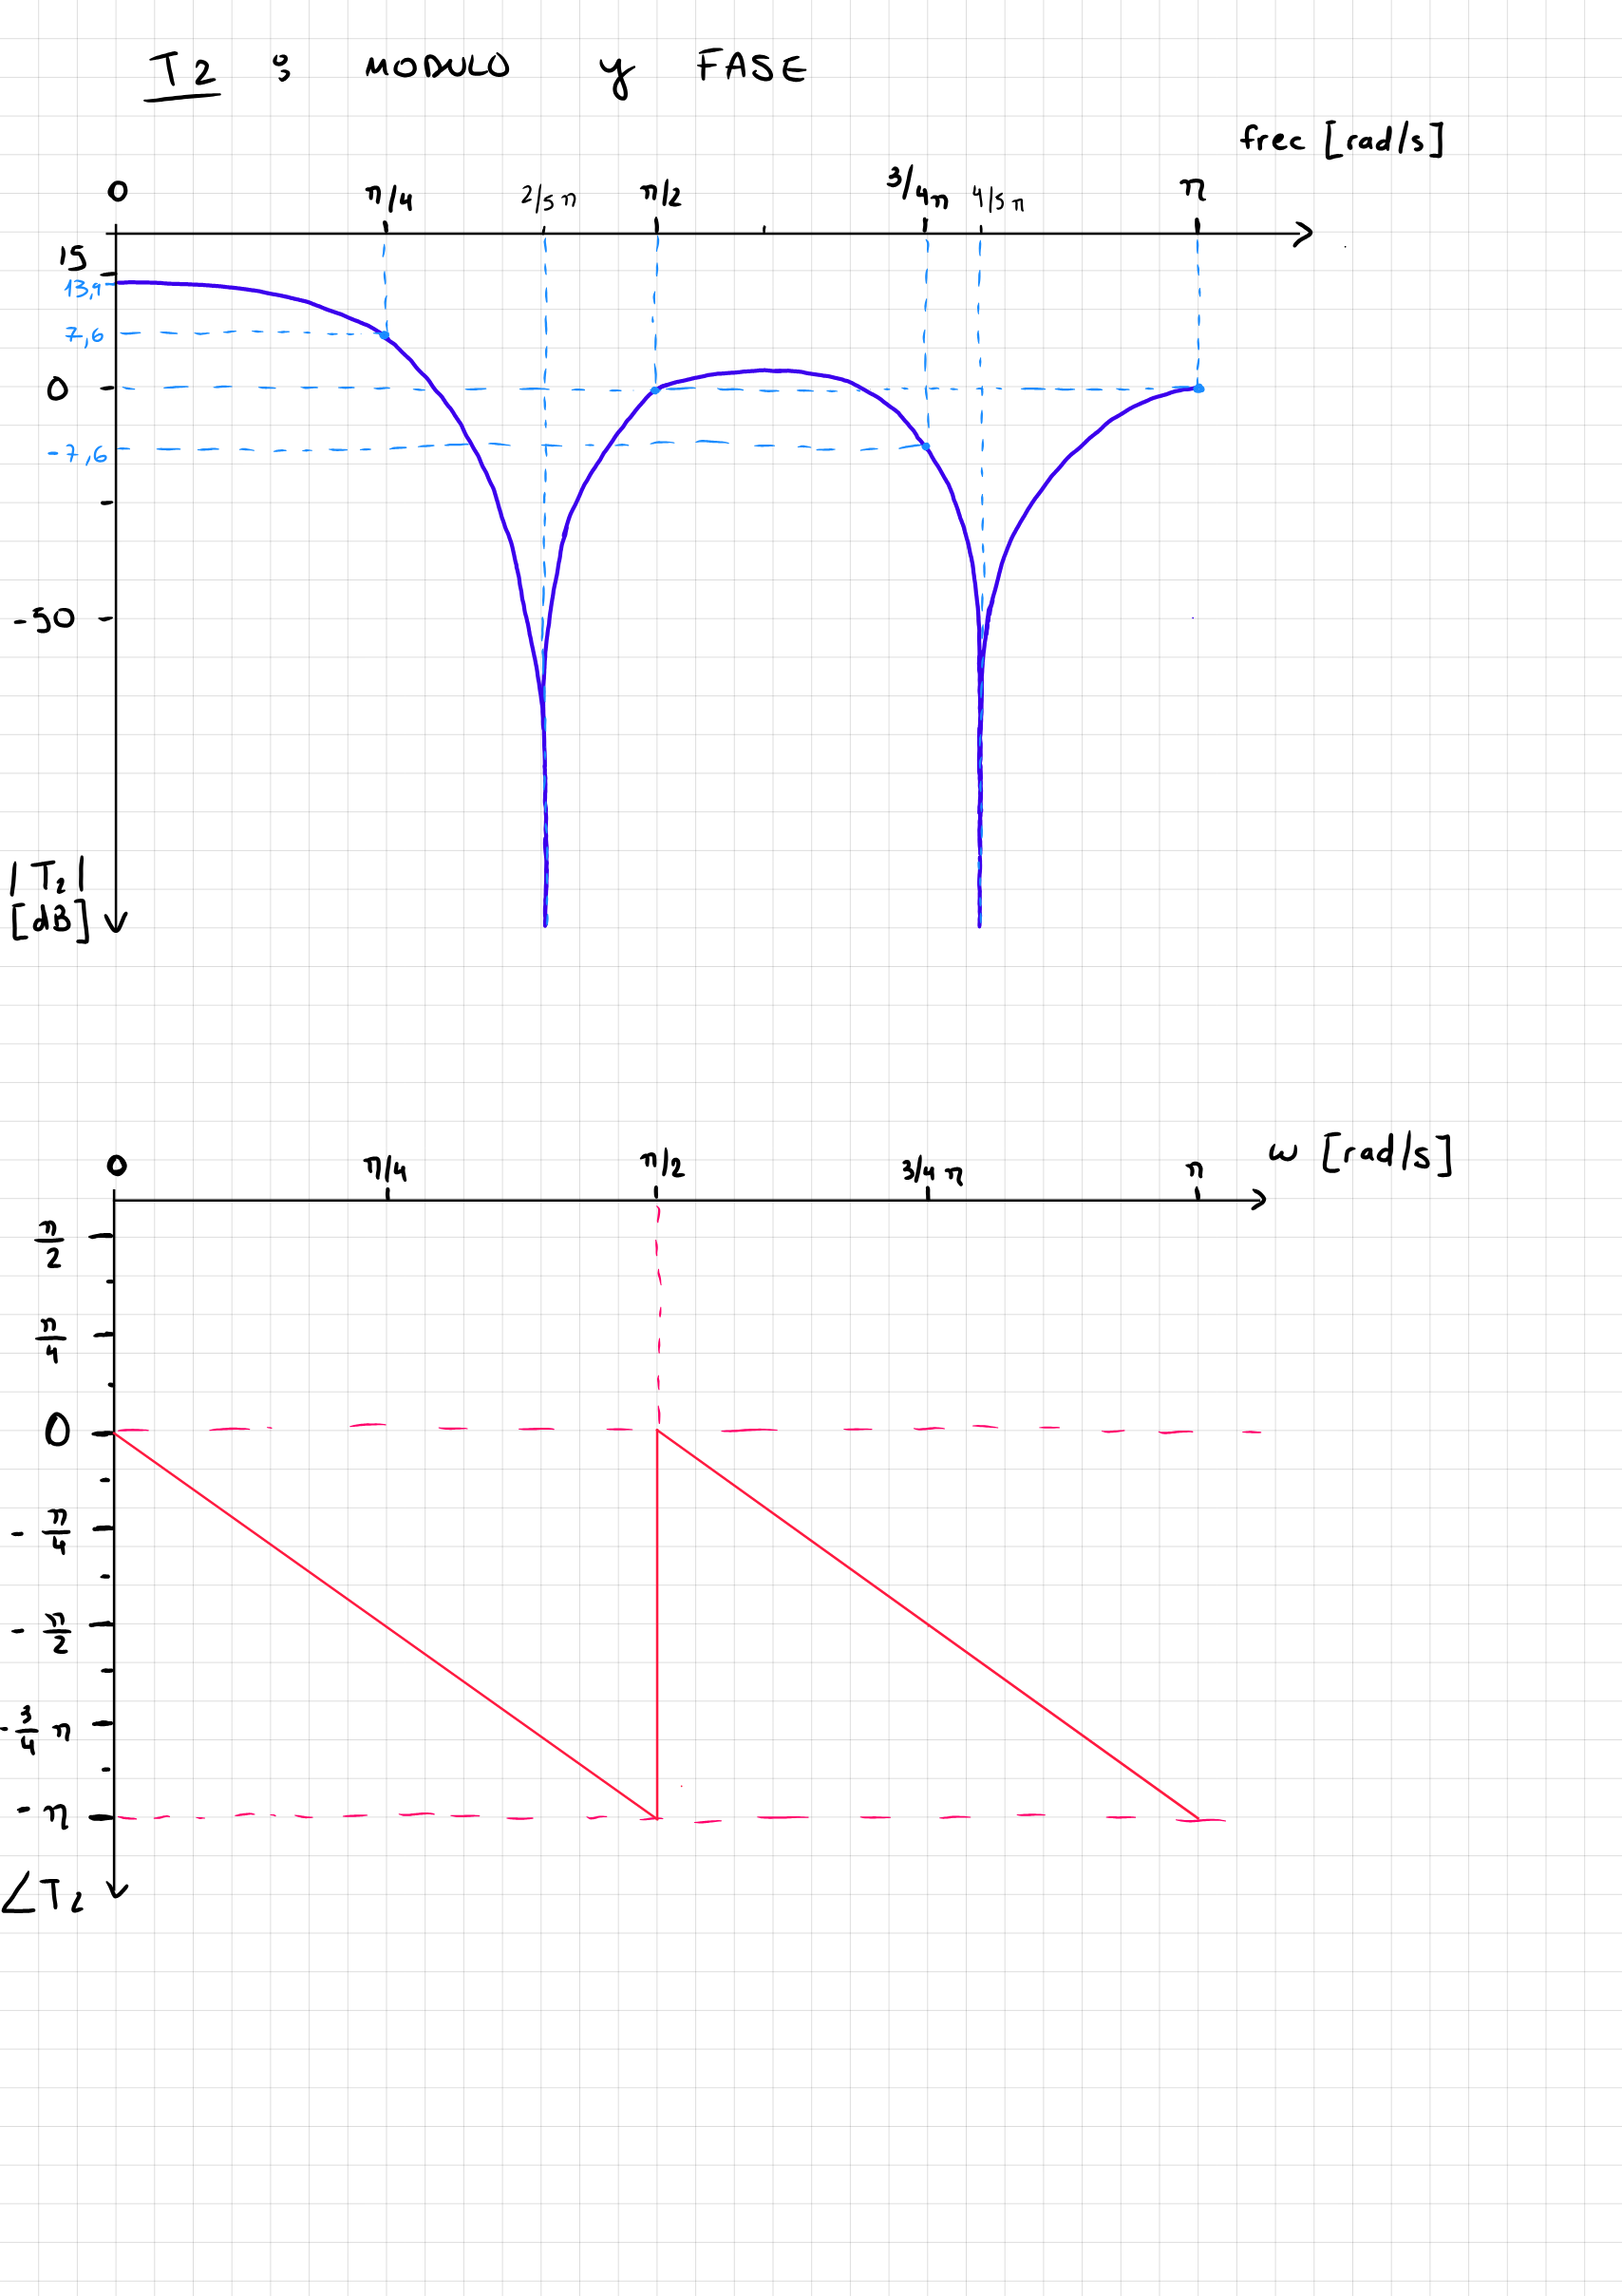

In [10]:
from IPython.display import Image 
Image(r"..\TS 6\grafT2.png")

$T_2$ es un filtro pasa-bajos de ***Tipo I***, tiene 5 coeficientes totales, lo que significa un $N=4$ par y simetrico, ya que todos toman el valor de $1$. No tiene ceros en $0$ ni en $\pi$, lo que indica que no cumple con ninguna restriccion, una caracteristica distintiva de filtros Tipo I. Los ceros del modulo en $w_0 = \frac{2\pi}{5}, \frac{4\pi}{5}$, implican una caida todavia mas pronunciada que el filtro de $T_1$ y una ganancia en DC de casi $14dB$. La fasees lineal con pendiente: $-2$.

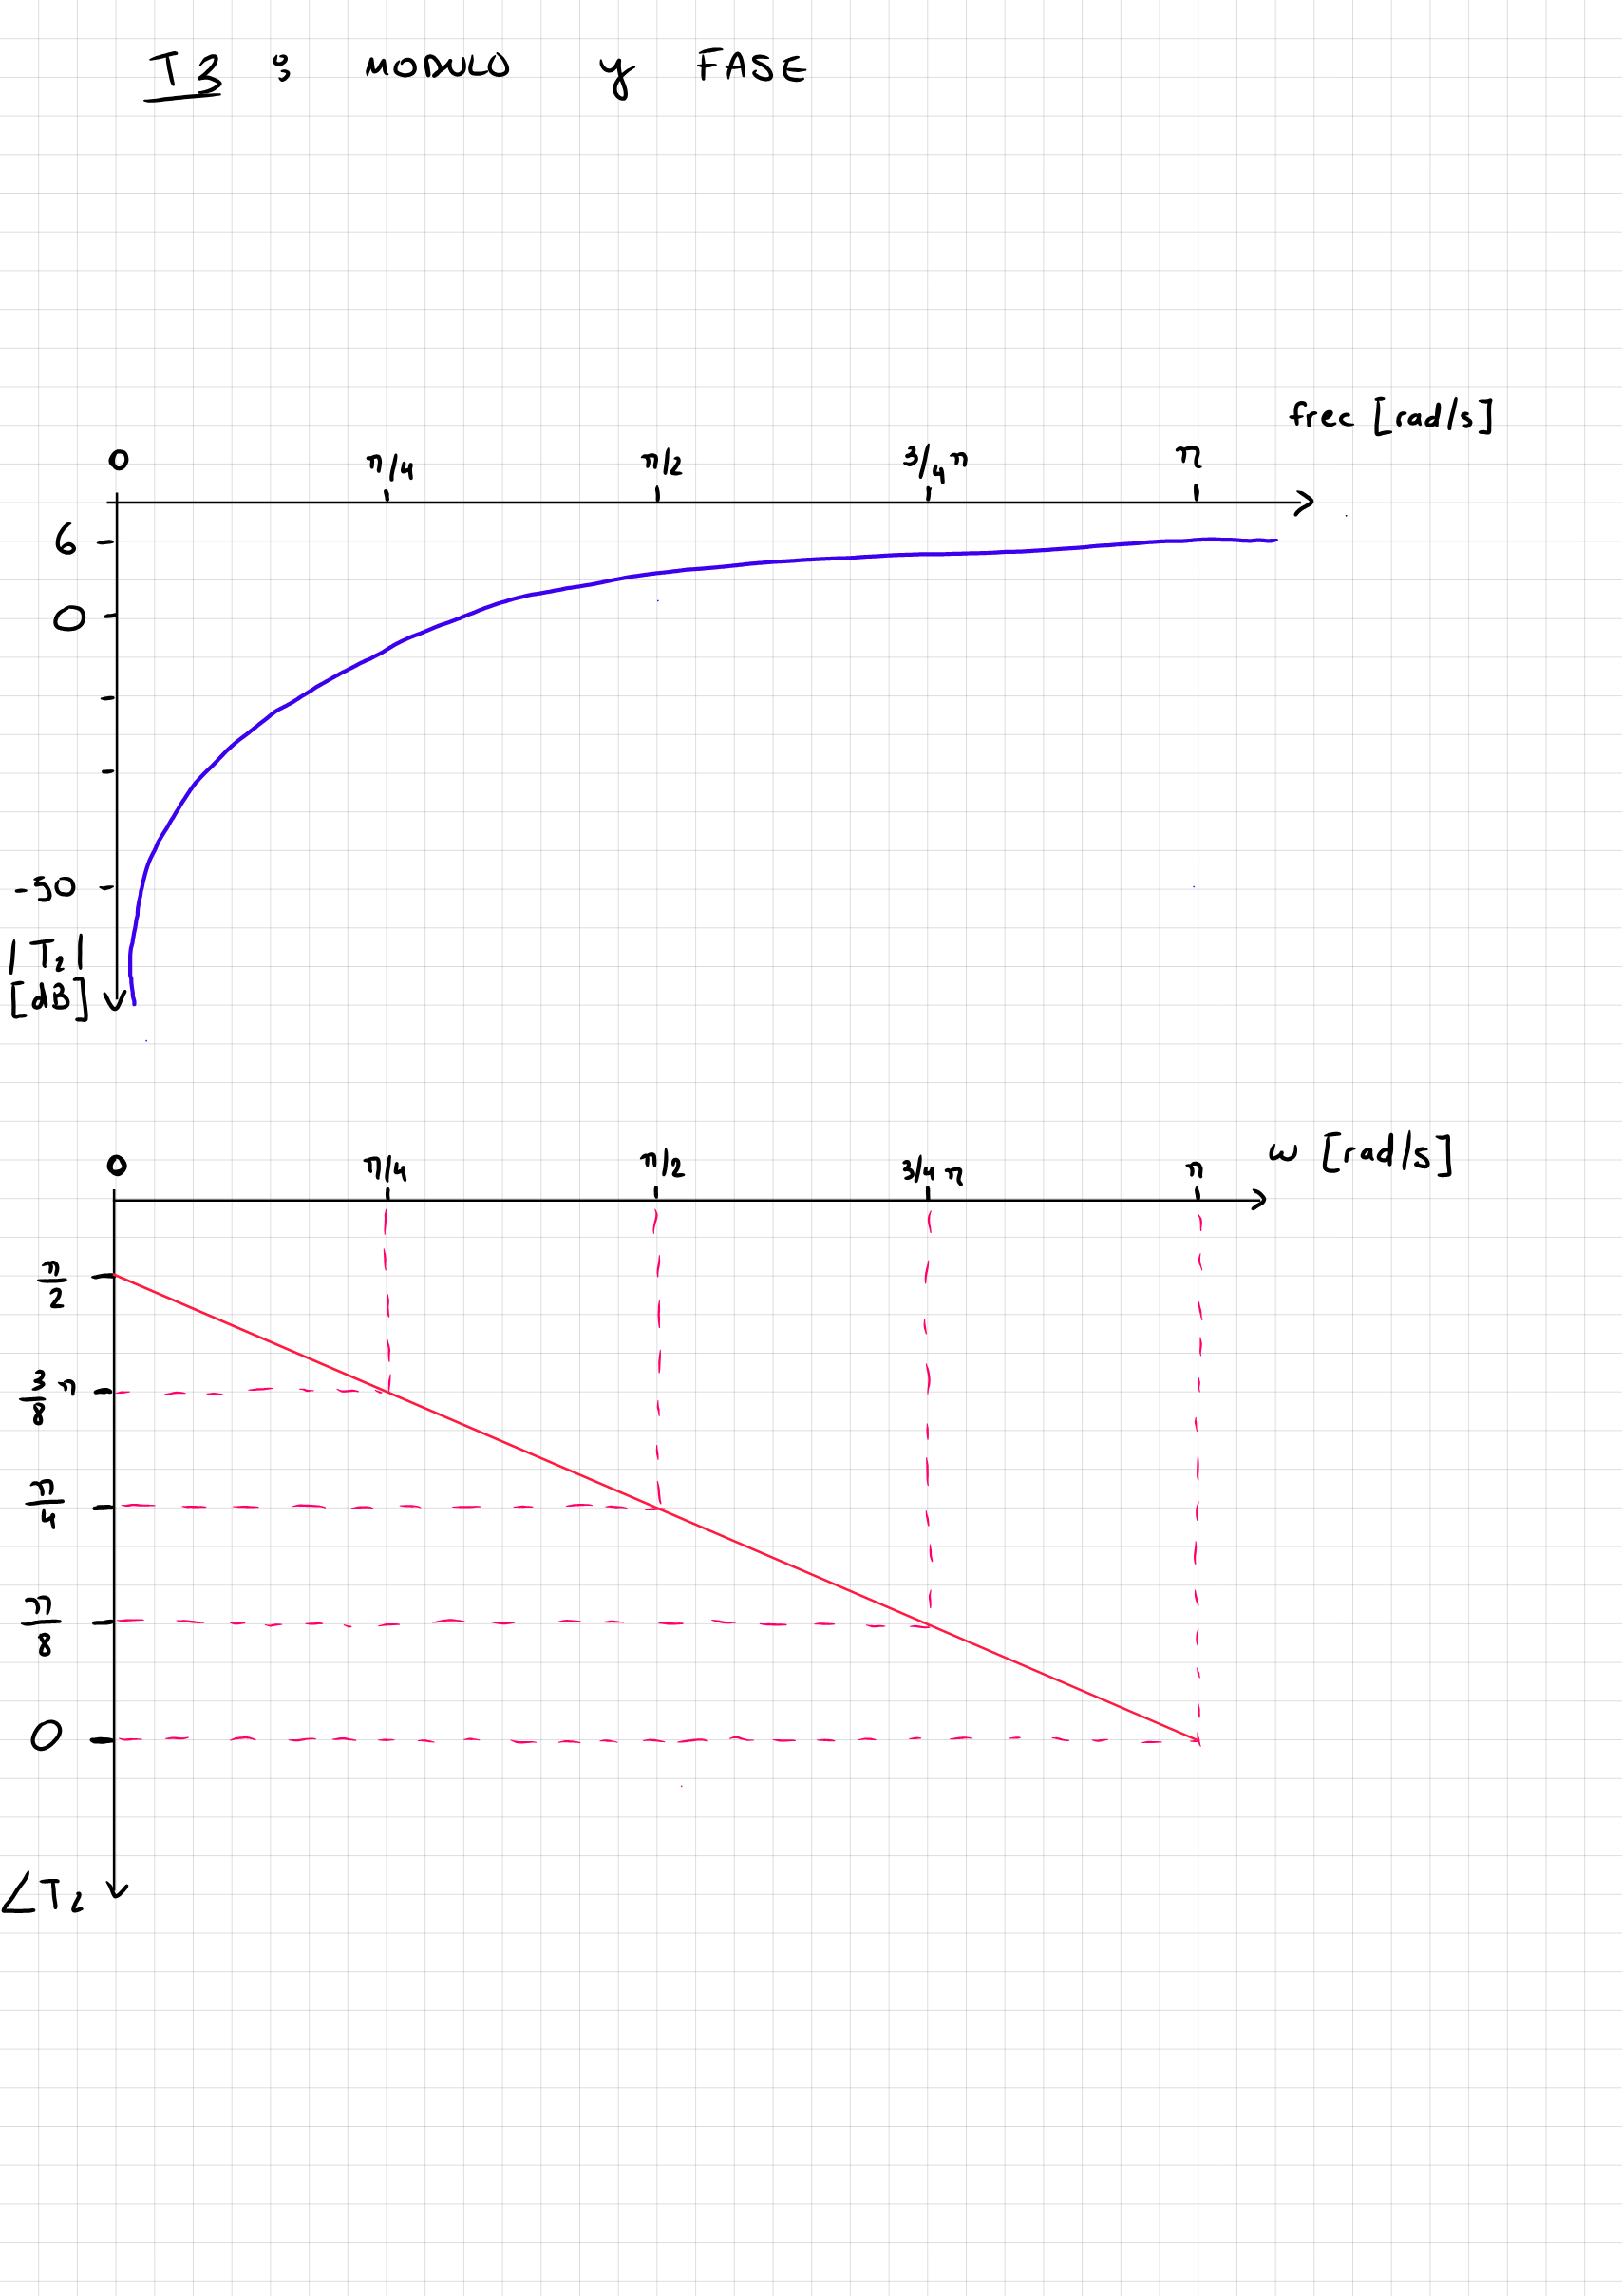

In [11]:
from IPython.display import Image 
Image(r"..\TS 6\grafT3.png")

La $T_3$, tiene coeficiente: $h = [1, -1]$ lo que indica un largo par de 2 muestras y $N=1$ y antisimetrico: $h[0] = -h[1] <-> 1 = -(-1)$. Ambas caracteristicas apuntan hacia un filtro **FIR** de ***Tipo IV*** pasa-altos. Se lo puede confirmar con su unico cero en $0$. Al ser de grado 1, solo contiene este cero, y por eso, crece desde $w = 0$ hasta $w=\pi$, donde alcanza su ganacia maxima de unos $6dB$.

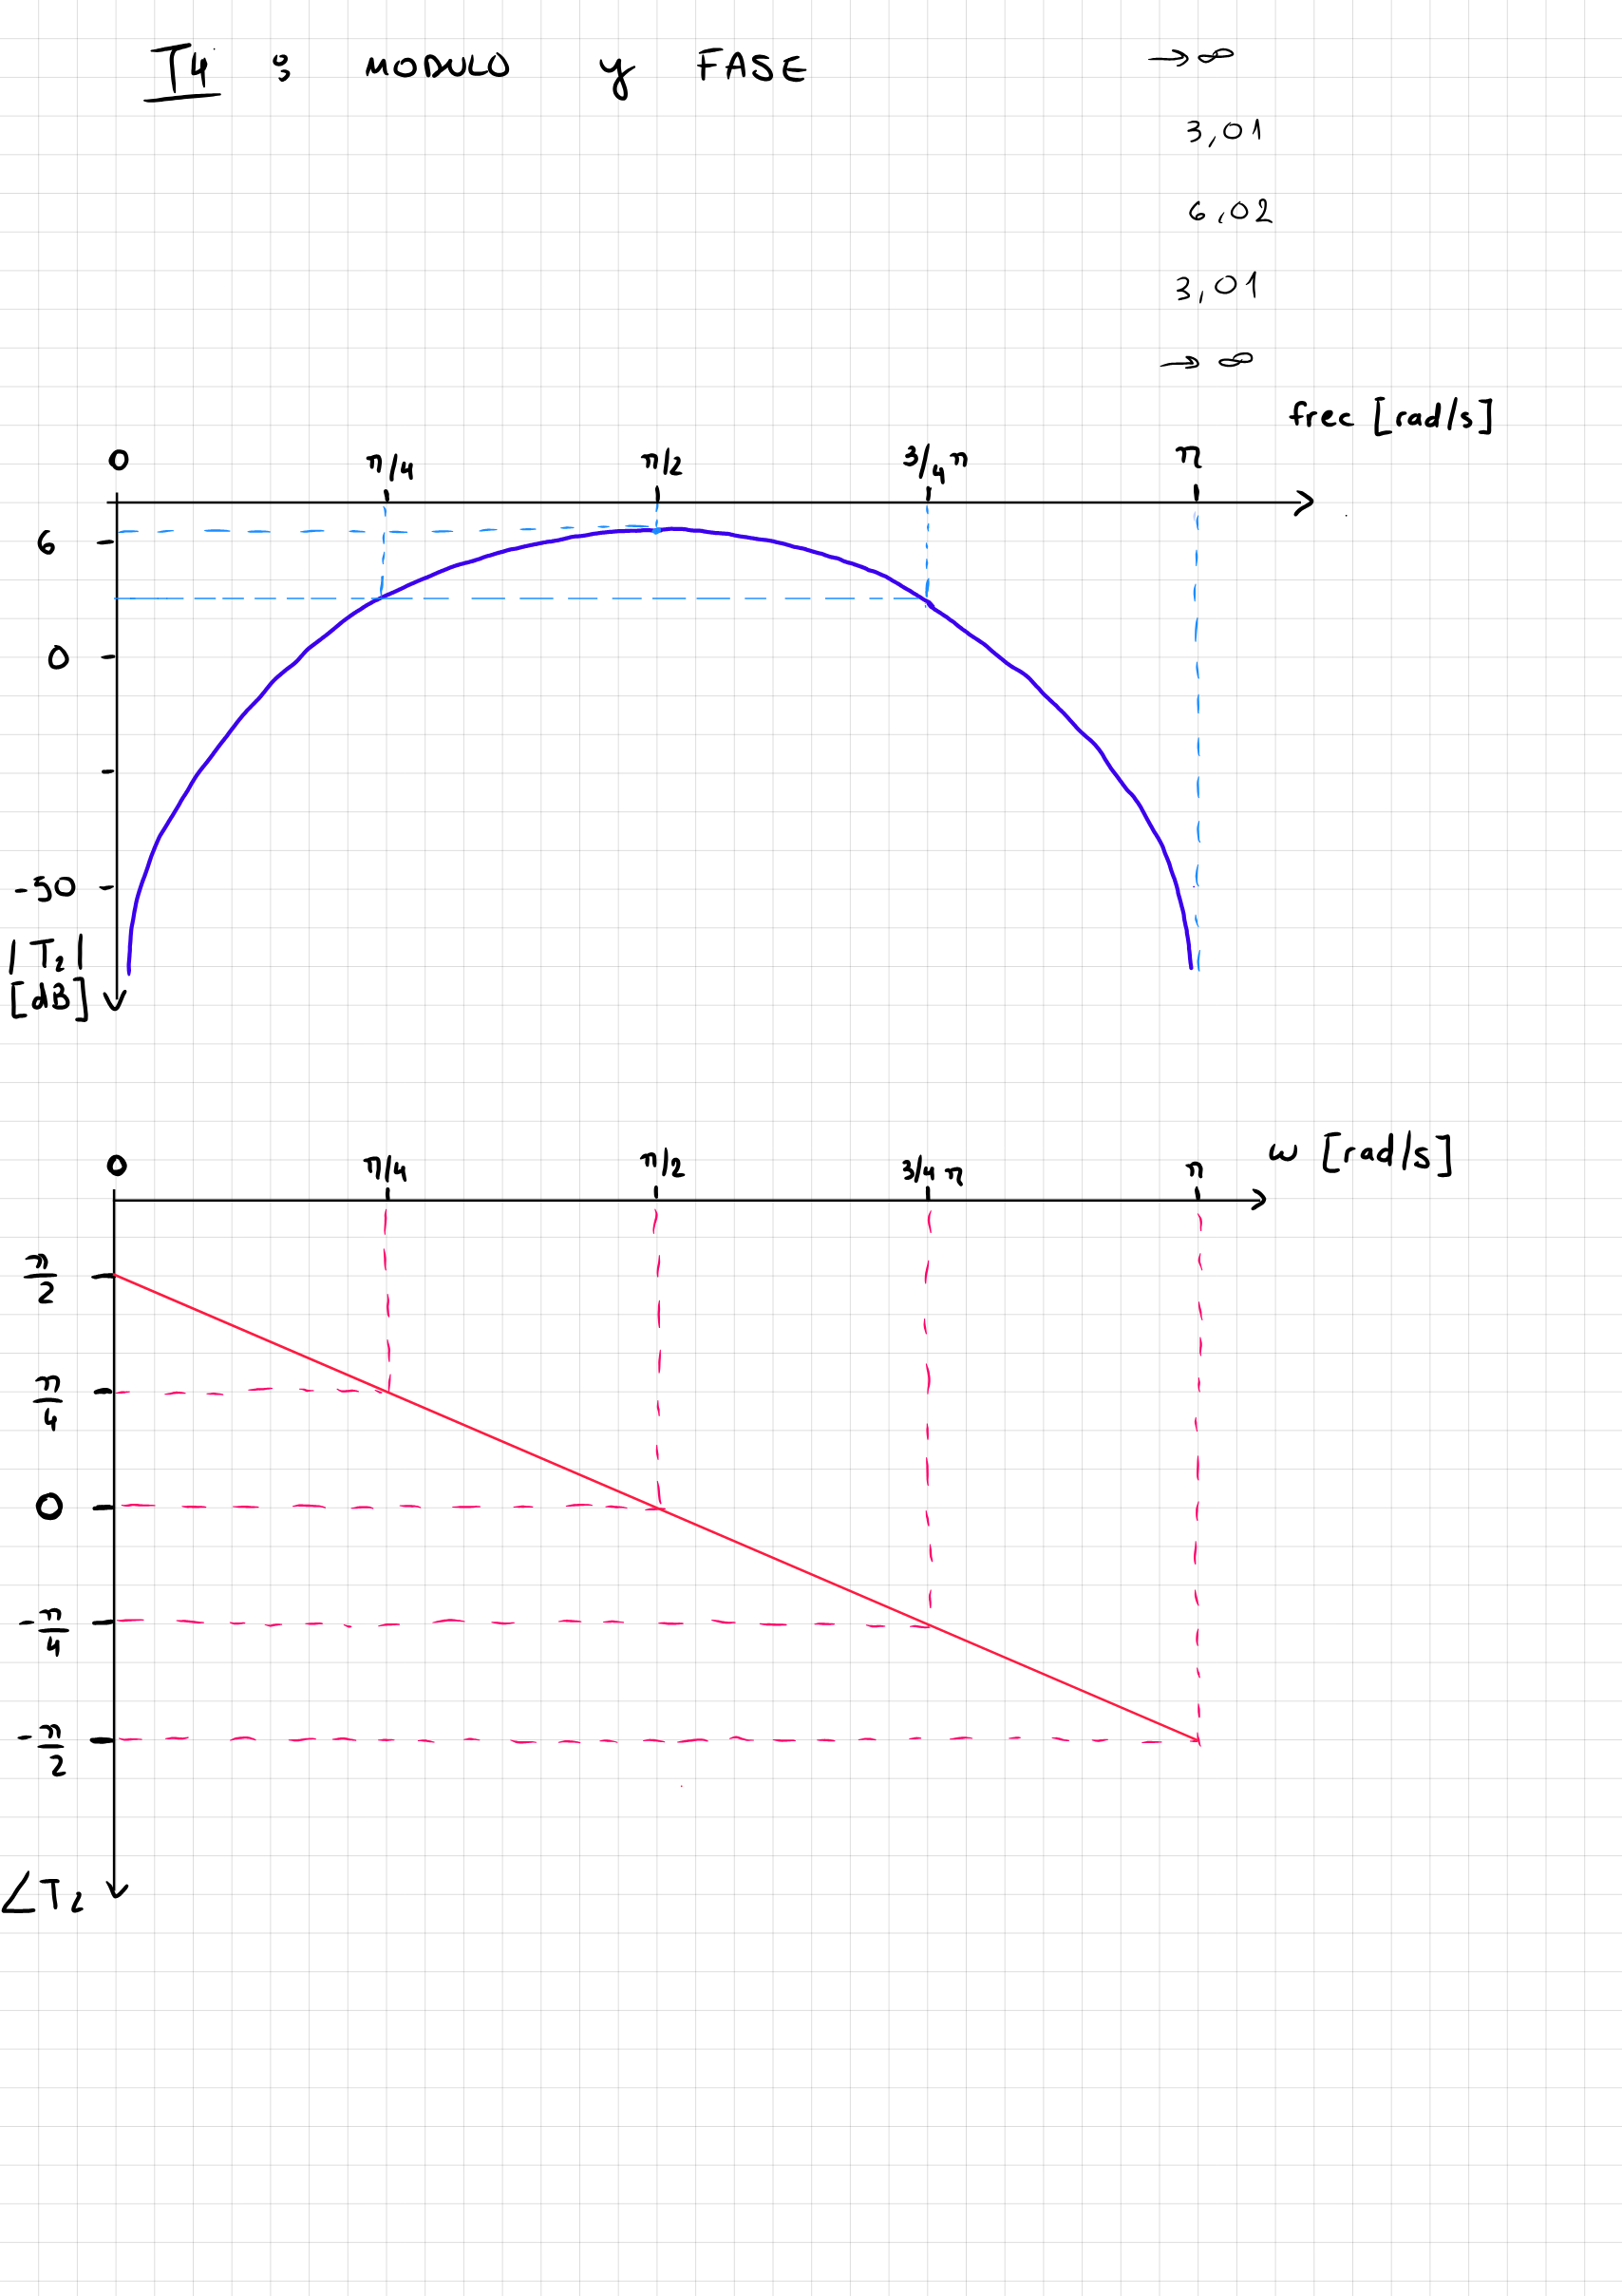

In [12]:
from IPython.display import Image 
Image(r"..\TS 6\grafT4.png")

Los coeficientes de $T_3$, $h= [1, 0, -1] $, presentan un $N=2$ y antisimetria: $h[0] = -h[2]$, lo que confirma un filtro pasa-banda ***Tipo III***. Ademas, el grafico de respuesta de modulo confirma esto, mostrando sus dos ceros estructurales obligatorios en $w_0 = [0, \pi]$, y una ganancia maxima para $w=\frac{\pi}{2}$ de $6dB$, dando un modulo simetrico. 

Por ultimo, se diseño, con asistencia de la AI un codigo que utilizando de variables de entrada los coeficientes de la funcion $T(z)$ y genera los graficos de polos y ceros, respuesta de modulo y respuesta de fase para cada sistema analizado. 

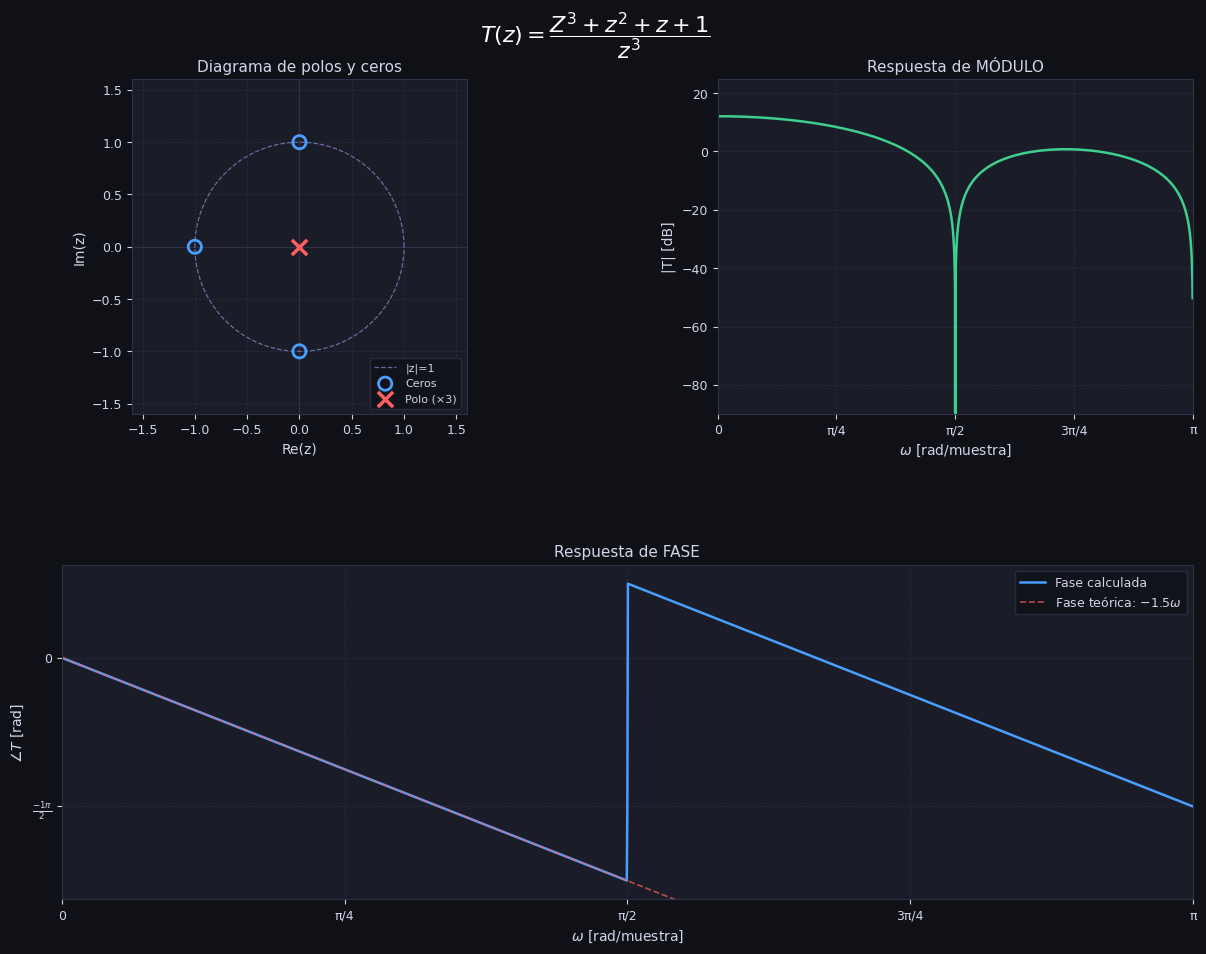

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal

# ─────────────────────────────────────────────
#%% PARÁMETROS 
# ─────────────────────────────────────────────
num = [ 1, 1, 1, 1]   # coeficientes del numerador  (potencias de z, mayor a menor)
den = [1, 0, 0, 0 ]   # coeficientes del denominador
titulo = r"$T(z) = \dfrac{Z^3 + z^2 + z + 1}{z^3}$"   # título del gráfico
label_polo = "p=0 (x3) "                    # multiplicidad del polo en origen

# ─────────────────────────────────────────────
#%% CÁLCULOS
# ─────────────────────────────────────────────

fs = 2 * np.pi
N  = 2048
zeros = np.roots(num)
poles = np.roots(den)
w, H      = signal.freqz(num, den, worN=N, fs=fs)
mag_dB    = 20 * np.log10(np.abs(H) + 1e-12)
phase_rad = np.unwrap(np.angle(H))
# Retardo de grupo: (grado_num - grado_den) / 2  →  pendiente teórica de fase
retardo = (len(num) - 1) / 2   # = (M-1)/2
phase_teo = -retardo * w
#%%
# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
DARK   = "#0f1117"
PANEL  = "#1a1d27"
GRID   = "#2e3147"
TEXT   = "#d0d4e8"
BLUE   = "#4a9eff"
RED    = "#ff5f5f"
GREEN  = "#3ecf8e"
YELLOW = "#f9c74f"
fig = plt.figure(figsize=(13, 10), facecolor=DARK)
fig.suptitle(titulo, fontsize=16, color="white", y=0.97)
gs = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38,
                       left=0.09, right=0.96, top=0.90, bottom=0.08)
ax_pz  = fig.add_subplot(gs[0, 0])
ax_mag = fig.add_subplot(gs[0, 1])
ax_ph  = fig.add_subplot(gs[1, :])
xticks  = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
xlabels = ["0", "π/4", "π/2", "3π/4", "π"]
for ax in [ax_pz, ax_mag, ax_ph]:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.grid(True, color=GRID, linewidth=0.6, linestyle="--", alpha=0.7)

#%% POLOS Y CEROS ─────────────────────────────
ax_pz.set_title("Diagrama de polos y ceros", fontsize=11)
ax_pz.set_xlabel("Re(z)")
ax_pz.set_ylabel("Im(z)")
ax_pz.set_aspect("equal")
ax_pz.axhline(0, color=GRID, linewidth=0.8)
ax_pz.axvline(0, color=GRID, linewidth=0.8)
theta = np.linspace(0, 2 * np.pi, 400)
ax_pz.plot(np.cos(theta), np.sin(theta),
           color="#6070a0", linewidth=0.9, linestyle="--", label="|z|=1")
ax_pz.scatter(zeros.real, zeros.imag,
              s=90, marker="o", facecolors="none",
              edgecolors=BLUE, linewidths=2, zorder=5, label="Ceros")
# Polos: agrupar duplicados en z=0
unique_poles, counts = np.unique(np.round(poles, 6), return_counts=True)
for p, c in zip(unique_poles, counts):
    ax_pz.scatter([p.real], [p.imag], s=120, marker="x",
                  color=RED, linewidths=2.5, zorder=5,
                  label=f"Polo (×{c})" if c > 1 else "Polo")
ax_pz.set_xlim(-1.6, 1.6)
ax_pz.set_ylim(-1.6, 1.6)
ax_pz.legend(fontsize=8, facecolor=DARK, edgecolor=GRID,
             labelcolor=TEXT, loc="lower right")

#%% MODULO ────────────────────────────────────
ax_mag.set_title("Respuesta de MÓDULO", fontsize=11)
ax_mag.set_xlabel(r"$\omega$ [rad/muestra]")
ax_mag.set_ylabel("|T| [dB]")
ax_mag.plot(w, mag_dB, color=GREEN, linewidth=1.8)
ax_mag.set_xlim(0, np.pi)
ax_mag.set_ylim(bottom=max(mag_dB.min() - 5, -90))
ax_mag.set_xticks(xticks)
ax_mag.set_xticklabels(xlabels)

#%% FASE ──────────────────────────────────────
ax_ph.set_title("Respuesta de FASE", fontsize=11)
ax_ph.set_xlabel(r"$\omega$ [rad/muestra]")
ax_ph.set_ylabel(r"$\angle T$ [rad]")
ax_ph.plot(w, phase_rad, color=BLUE, linewidth=1.8, label="Fase calculada")
ax_ph.plot(w, phase_teo, color=RED, linewidth=1.2, linestyle="--", alpha=0.7,
           label=rf"Fase teórica: $-{retardo}\omega$")
ax_ph.set_xlim(0, np.pi)
ax_ph.set_xticks(xticks)
ax_ph.set_xticklabels(xlabels)
ax_ph.legend(fontsize=9, facecolor=DARK, edgecolor=GRID, labelcolor=TEXT)

# Yticks de fase en unidades de π
fase_min = phase_rad.min()
fase_max = phase_rad.max()
yticks_fase = np.arange(np.floor(fase_min / np.pi), np.ceil(fase_max / np.pi) + 0.5, 0.5) * np.pi
ylabels_fase = []
for v in yticks_fase:
    frac = v / np.pi
    if frac == 0:
        ylabels_fase.append("0")
    elif frac == 1:
        ylabels_fase.append("π")
    elif frac == -1:
        ylabels_fase.append("−π")
    elif frac == int(frac):
        ylabels_fase.append(f"{int(frac)}π")
    else:
        from fractions import Fraction
        f = Fraction(frac).limit_denominator(8)
        ylabels_fase.append(rf"$\frac{{{f.numerator}\pi}}{{{f.denominator}}}$")
ax_ph.set_yticks(yticks_fase)
ax_ph.set_ylim(fase_min - 0.2, fase_max + 0.2)
ax_ph.set_yticklabels(ylabels_fase)

plt.show()

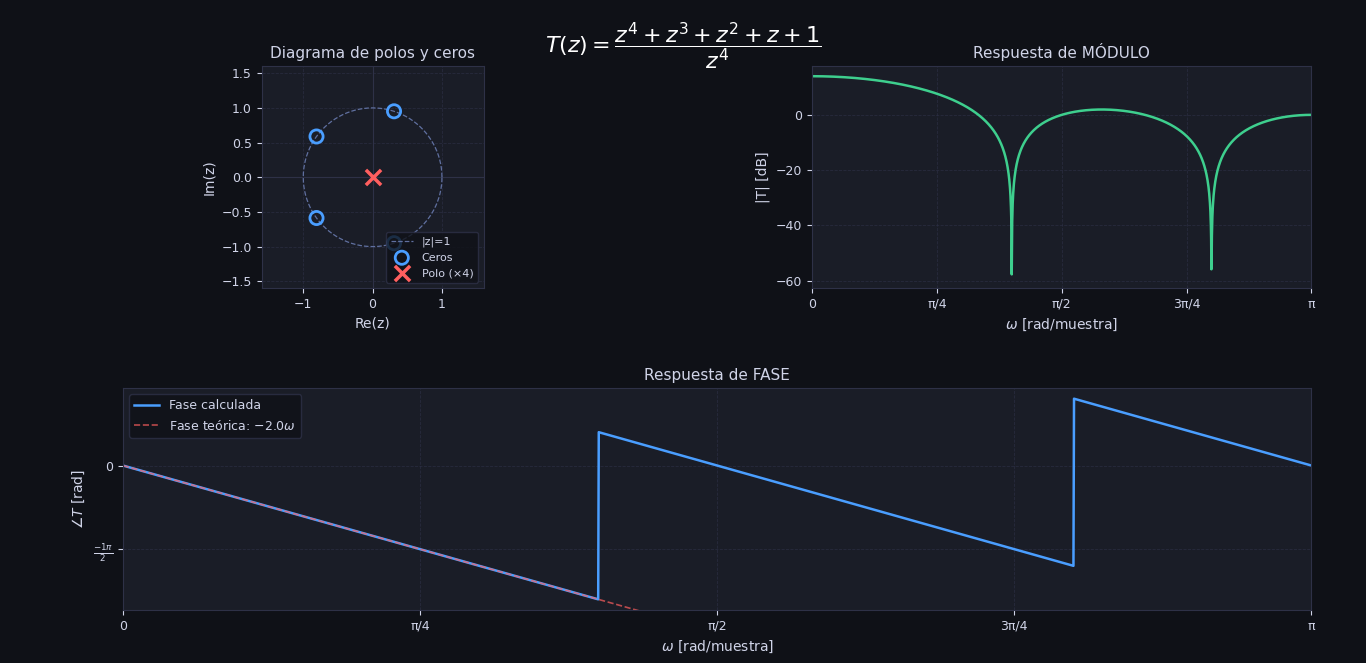

In [1]:
from IPython.display import Image 
Image(r"..\TS 6\T2.png")

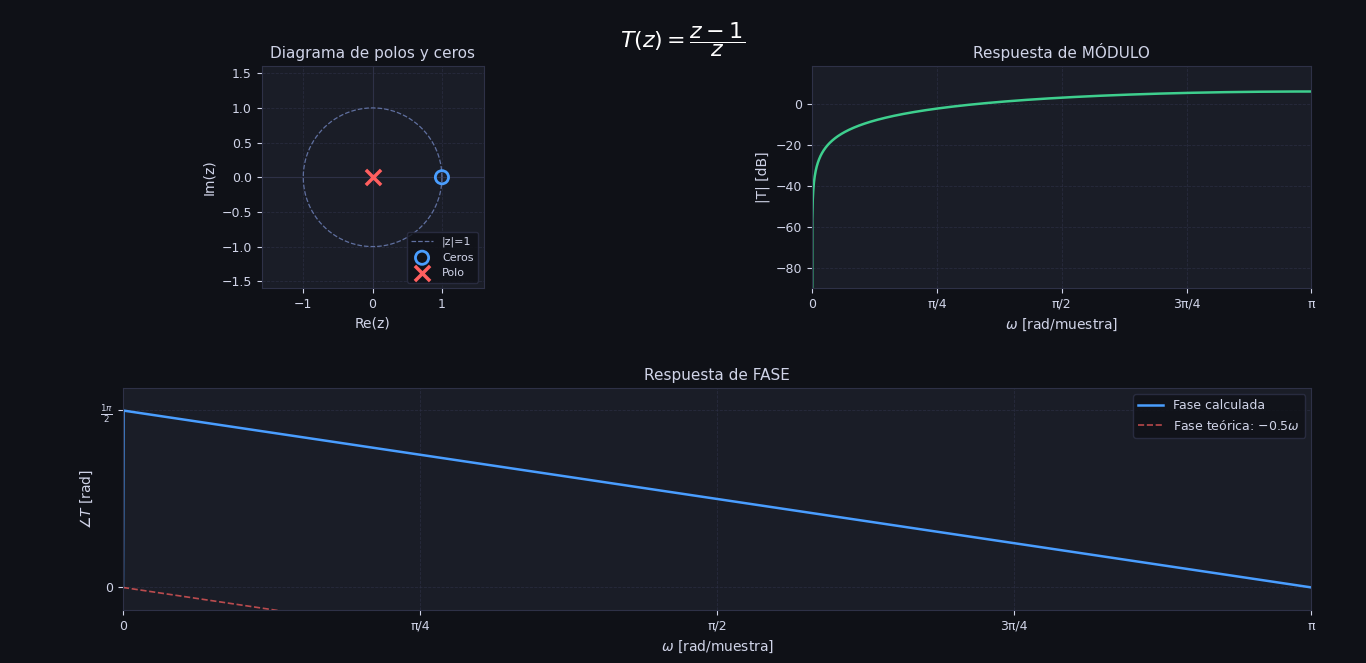

In [2]:
from IPython.display import Image 
Image(r"..\TS 6\T3.png")

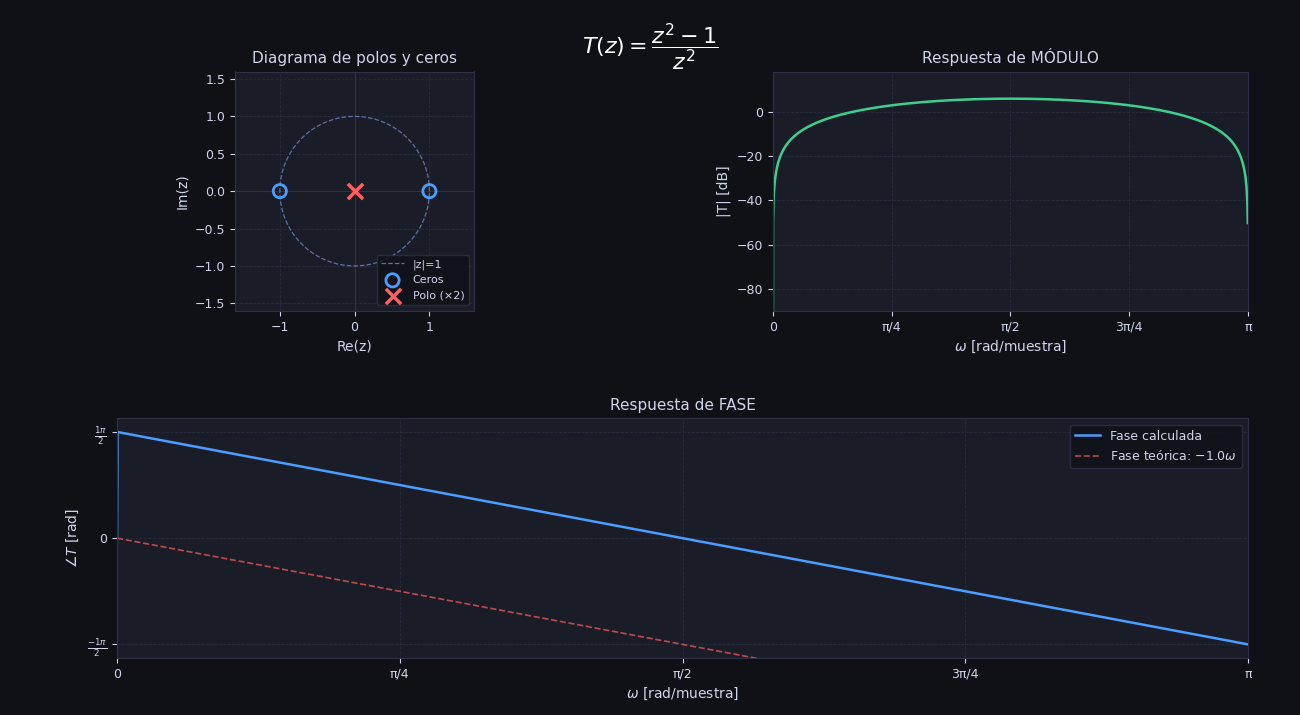

In [3]:
from IPython.display import Image 
Image(r"..\TS 6\T4.png")

Los graficos obtenidos por el codigo de los ceros y polos y las respuestas en frecuencia de modulo y fase coinciden con el analisis teorico realizado. Se respetan los puntos claves de cada grafico, como por ejemplo, los ceros sobre el circulo unitario, la cantidad de polos, los puntos claves en donde el modulo tiende a menos infinito y aproximadamente sus puntos de maxima ganancia y la pendiente de la respuesta de fase. Los graficos son mas precisos, detallados y ordenados y el codigo ayuda a minimizar el tiempo de ejecucion de los calculos pero no es una herramienta indispensable. El analisis manual fue capaz de caracterizar todos los filtros. 

A lo largo de este trabajo se analizaron cuatro funciones de transferencia de filtros FIR. Donde, para cada una se calcularon y graficaron sus polos y ceros, se obtuvo su respuesta en frecuencia analizando tanto su comportamiento de modulo como el de fase. A partir de este analisi, se caracterizo cada filtro segun la clasificaion de tipos FIR. Finalmente, se corroboraron todos los resultados mediante la simulacion, obteniendo una coincidencia exacta, lo que vlida los metodosteoricos utilizados.